In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESMC2/bin'

In [2]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
# from ESMCBA import graph_utils
# from ESMCBA import other_utils
# import importlib
# importlib.reload(other_utils)
from pathlib import Path

In [3]:
training_files = glob.glob('/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA*final.csv')

In [4]:
import os
import pandas as pd
from collections import defaultdict

# Initialize data structures
HLA_size = []  # For DataFrame rows => [File, Epitope Count, HLA, HLA_type]
ic50_by_hla = defaultdict(list)
ic50_by_hla_type = defaultdict(list)
source_by_hla_type = defaultdict(list)

for file in training_files:
    # Skip any file that contains 'HLAHLA' in its name
    if 'HLAHLA' in file:
        continue
    
    # Skip if file doesn't exist or is empty
    if not os.path.exists(file) or os.path.getsize(file) == 0:
        continue
    
    # Now read the CSV since the file isn't empty
    df = pd.read_csv(file, sep=',', header=None)
    
    # If the DataFrame itself is empty (no rows)
    if df.empty:
        continue  # skip
    
    # Count unique values in the first column (for 'Epitope Count')
    epitope_count = len(df[0].unique())
    
    # Extract HLA and HLA_type from the filename
    filename_part = os.path.basename(file)
    # e.g. if your file format is "xxx_HLA-A01_yyy.csv"
    hla_full = filename_part.split('_')[1]  # e.g. "HLA-A01"
    hla_type = hla_full[3]                 # e.g. "A"
    
    # Store in HLA_size list for later DataFrame creation
    HLA_size.append([file, epitope_count, hla_full, hla_type])
    
    if 'A0201' in file:
        break 

    # If column 7 exists, collect IC50 values
    if 7 in df.columns:
        ic50_values = df[7].tolist()
        source = df[6].tolist()
        ic50_by_hla[hla_full].extend(ic50_values)
        ic50_by_hla_type[hla_type].extend(ic50_values)
        source_by_hla_type[hla_type].extend(source)

# Convert the collected HLA_size info into a DataFrame
IEDB_data = pd.DataFrame(HLA_size, columns=['File', 'Epitope Count', 'HLA', 'HLA_type'])

# Optionally, filter out certain HLA types if needed
IEDB_data = IEDB_data[IEDB_data['HLA_type'] != 'E']

# Now you have:
# 1) A DataFrame "IEDB_data" with columns [File, Epitope Count, HLA, HLA_type]
# 2) A dictionary "ic50_by_hla" mapping full HLA => list of IC50
# 3) A dictionary "ic50_by_hla_type" mapping single-letter type => list of IC50

In [44]:
IEDB_data[IEDB_data['HLA_type'] != 'D']['HLA'].nunique()

121

In [29]:
from matplotlib.ticker import FixedLocator, ScalarFormatter

plt.figure(figsize=(5, 4))

order = ["A", "B", "C"]

# Convert HLA_type to a categorical with that specific order, then sort
IEDB_data['HLA_type'] = pd.Categorical(IEDB_data['HLA_type'], categories=order, ordered=True)
IEDB_data = IEDB_data.dropna(subset=['HLA_type']).sort_values('HLA_type')

# Prepare a mapping of color per HLA type
color_map = {
    'A': 'C0',
    'B': 'C1',
    'C': 'C2',
    # 'D': 'C3'
}

# Unique types in the specified order
unique_types = order
x_positions = np.arange(len(unique_types))

for i, hla in enumerate(unique_types):

    if 'D' in hla:
        continue

    subset = IEDB_data[IEDB_data['HLA_type'] == hla]
    if subset.empty:
        continue
    
    # Spread points horizontally so they don't overlap
    n = len(subset)
    offsets = np.linspace(-0.2, 0.2, n)
    x_coords = x_positions[i] + offsets
    
    # Store the scatter points with their coordinates
    plt.scatter(
        x_coords,
        subset['Epitope Count'],
        edgecolor='black',
        linewidth=1.0,
        s=50
    )
    
    # Get the top point
    top1 = subset.nlargest(1, 'Epitope Count')
    
    for idx, row in top1.iterrows():
        # Find the corresponding x-coordinate from our scatter
        row_idx = subset.index.get_loc(idx)
        x_val = x_coords[row_idx]
        y_val = row['Epitope Count']
        
                # Flip label to left if it's HLA-C
        if hla == "C":
            xytext = (x_val - 0.15, y_val * 2)  # Left
            ha = 'right'
        else:
            xytext = (x_val + 0.25, y_val * 2)  # Right
            ha = 'left'

        plt.annotate(
            row['HLA'],
            xy=(x_val, y_val),
            xytext=xytext,
            arrowprops=dict(
                arrowstyle="->",
                connectionstyle="arc3,rad=0.1",
                linewidth=1.0
            ),
            fontsize=10,
            ha=ha,
            va='bottom',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )


# Set up log scale with specific y-ticks
ax = plt.gca()
ax.set_yscale('log')
ax.yaxis.set_major_locator(FixedLocator([10, 100, 1000, 10000, 100000]))  # Only these exact values
ax.yaxis.set_major_formatter(ScalarFormatter())  # Plain numbers
ax.set_ylim(-5, 50000)  # Adjusted limits to keep labels visible

# Customize x tick labels
x_labels = [f"HLA-{x}" for x in unique_types]
plt.xticks(x_positions, x_labels, size = 12)

plt.xlabel('HLA Type', size = 12)
plt.ylabel('Epitope Count', size = 12)
  
# # Save the figure with the HLA name in the specified folder.
out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
out_dir.mkdir(parents=True, exist_ok=True)      
save_path = out_dir / f"fig1.pdf"
fig = plt.gcf()                                 # or keep a handle from plt.subplots()
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close(fig)   

plt.tight_layout()
plt.show()

/tmp/ipykernel_21188/1358283532.py:84: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(-5, 50000)  # Adjusted limits to keep labels visible


<Figure size 640x480 with 0 Axes>

In [27]:
hla

'C'

In [6]:
IEDB_data [IEDB_data['HLA'] == 'HLAA0201']['File'].iloc[0]


'/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAA0201_final.csv'

In [7]:
dt = pd.read_csv('/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAA0201_final.csv', sep=',', header=None).head(5)

/tmp/ipykernel_21188/3356132535.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(
/tmp/ipykernel_21188/3356132535.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


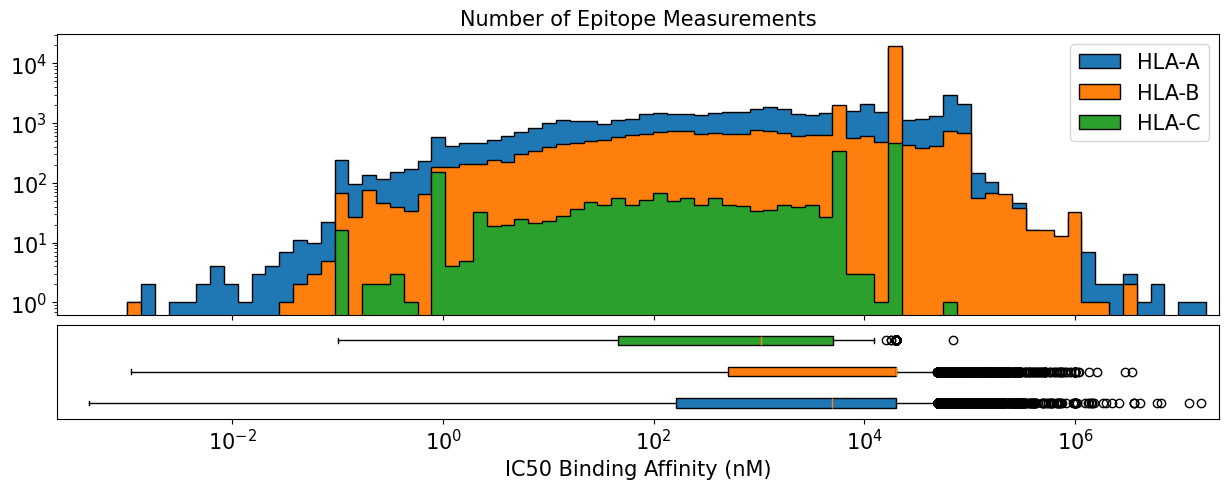

In [ ]:
modelv

  

In [10]:
from collections import Counter
import itertools

# Flatten all lists from source_by_hla_type.values() into a single list
all_sources = list(itertools.chain(*source_by_hla_type.values()))

# Count occurrences of each source
source_counts = Counter(all_sources)

# Print the result
print(source_counts)

Counter({'\\N': 63911, 'Vaccinia virus WR (Vaccinia virus (strain WR))': 14260, 'Phleum pratense (timothy grass)': 13927, 'Homo sapiens (human)': 8622, 'SARS-CoV1': 8058, 'Mycobacterium tuberculosis': 3308, 'Zaire ebolavirus (Ebola virus Zaire strain)': 3032, 'Giardia lamblia ATCC 50803': 2589, 'Mammarenavirus brazilense (Brazilian mammarenavirus)': 2409, 'Vaccinia virus (vaccinia virus VV)': 2195, 'Dengue virus 2 Jamaica/1409/1983 (Dengue virus type 2 (strain Jamaica))': 2106, 'Dengue virus 1 Brazil/97-11/1997 (Dengue virus type 1 Brazil/97-11/1997)': 1707, 'Mammarenavirus juninense (Argentinian mammarenavirus)': 1440, 'Mammarenavirus guanaritoense (Guanarito arenavirus)': 1429, 'Vaccinia virus Copenhagen (Vaccinia virus (strain Copenhagen))': 1416, 'Mycobacterium tuberculosis H37Rv (Mycobacterium tuberculosis str. H37Rv)': 1395, 'Mammarenavirus lassaense (Lassa mammarenavirus)': 1377, 'Mammarenavirus machupoense (Machupo mammarenavirus)': 1146, 'Plasmodium falciparum 3D7': 1080, 'SAR

In [11]:
from collections import Counter, defaultdict
import re

# Sample of your counter data (in practice you'd use the full counter)
counter_data = source_counts

# Function to categorize organisms
def categorize_organism(organism_name):
    if organism_name == '\\N':
        return 'unknown'
        
    name_lower = organism_name.lower()
    
    # Categories with their keywords
    categories = {
        'virus': ['virus', 'viral', 'viridae', 'phage', 'pox', 'herpes', 'influenza', 
                 'dengue', 'ebola', 'corona', 'hepatitis', 'hiv', 'sars', 'rotavirus', 
                 'cov', 'orthohantavirus', 'flavivirus', 'marburgvirus', 'arenavirus', 
                 'mammarenavirus', 'vaccinia', 'lyssavirus'],
        'bacteria': ['bacterium', 'bacillus', 'coccus', 'vibrio', 'escherichia', 
                    'salmonella', 'mycobacterium', 'brucella', 'rickettsia', 'coxiella', 
                    'francisella', 'listeria', 'clostridium', 'pseudomonas', 'shigella', 
                    'yersinia', 'corynebacterium', 'bordetella', 'streptococcus', 
                    'burkholderia', 'e. coli', 'campylobacter', 'mycolicibacterium'],
        'parasite': ['plasmodium', 'trypanosoma', 'cryptosporidium', 'giardia', 
                    'entamoeba', 'toxoplasma', 'schistosoma', 'encephalitozoon'],
        'plant': ['grass', 'birch', 'wheat', 'oak', 'ragweed', 'juniper', 'cypress', 
                 'pratensis', 'aestivum', 'cynodon', 'poa', 'lolium', 'phleum', 
                 'dactylis', 'timothy', 'alnus', 'quercus', 'betula', 'plantago', 
                 'artemisia', 'triticum', 'anthoxanthum', 'kali'],
        'animal': ['homo sapiens', 'human', 'dog', 'cat', 'horse', 'pig', 'rat', 
                  'mouse', 'chicken', 'bird', 'bovine', 'canis', 'felis', 'gallus', 
                  'rattus', 'mus', 'bos', 'sus', 'equus', 'gorilla', 'pan', 'monkey', 
                  'ape', 'dust mite', 'cockroach', 'bee', 'apis', 'blattella', 
                  'dermatophagoides', 'callithrix', 'tarsius', 'ateles', 'columba', 
                  'xenopus', 'heloderma', 'physeter'],
        'fungus': ['candida', 'aspergillus', 'penicillium', 'cladosporium', 
                  'alternaria', 'paracoccidioides']
    }
    
    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in name_lower:
                return category
    
    return 'other'

# Create a mapping dictionary from organism to category
organism_to_category = {organism: categorize_organism(organism) for organism in counter_data.keys()}

# Create a new counter for categories
category_counter = Counter()
for organism, count in counter_data.items():
    category = organism_to_category[organism]
    category_counter[category] += count

# Create a dictionary where categories are keys and values are dicts of {organism: count}
categorized_data = defaultdict(dict)
for organism, count in counter_data.items():
    category = organism_to_category[organism]
    categorized_data[category][organism] = count

# Print summary
print("Summary of categories:")
for category, count in category_counter.most_common():
    print(f"{category}: {count} total count, {len(categorized_data[category])} unique organisms")

# Create a reference dictionary mapping each organism to its category
organism_categories = {organism: category for organism, category in organism_to_category.items()}

# Output the first few entries from the reference dictionary
print("\nSample of organism categorization:")
for i, (organism, category) in enumerate(organism_categories.items()):
    if i < 10:  # Just show the first 10
        print(f"{organism} -> {category}")

Summary of categories:
virus: 70012 total count, 566 unique organisms
unknown: 63911 total count, 1 unique organisms
bacteria: 24653 total count, 314 unique organisms
plant: 17890 total count, 16 unique organisms
animal: 12655 total count, 33 unique organisms
parasite: 7162 total count, 28 unique organisms
fungus: 1463 total count, 9 unique organisms
other: 1014 total count, 89 unique organisms

Sample of organism categorization:
Phleum pratense (timothy grass) -> plant
Influenza A virus (A/Shanghai/4665T/2013(H7N9)) -> virus
Human immunodeficiency virus 1 (human immunodeficiency virus 1 HIV-1) -> virus
Human immunodeficiency virus type 1 BH10 (Human immunodeficiency virus type 1 (BH10 ISOLATE)) -> virus
Human immunodeficiency virus type 1 (CDC-451 ISOLATE) -> virus
Staphylococcus aureus -> bacteria
Human immunodeficiency virus type 1 (MAL ISOLATE) -> virus
Human herpesvirus 4 (Epstein Barr virus) -> virus
dengue virus type 1 (dengue type 1 D1 virus) -> virus
Homo sapiens (human) -> an

In [12]:
organism_to_category = {organism: categorize_organism(organism) for organism in counter_data.keys()}
category_counter = Counter()
for organism, count in counter_data.items():
    category = organism_to_category[organism]
    category_counter[category] += count

categories = list(category_counter.keys())
counts = list(category_counter.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, 
               color='skyblue',        # Fill color
               edgecolor='black',      # Outline for each bar
               linewidth=1.2,          # Thickness of outline
               alpha=0.8)              # Slight transparency

plt.yscale('log')  # Log scale due to large range (e.g., 70390 for 'unknown')
plt.ylabel('Total Epitope Count (log scale)', fontsize=15)

# Rotate and align x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontsize=12)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{int(height):,}',  # Format with commas for readability
             ha='center', va='bottom', fontsize=15, color='black')

out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
out_dir.mkdir(parents=True, exist_ok=True)      
save_path = out_dir / f"fig1c.pdf"
fig = plt.gcf()                                 # or keep a handle from plt.subplots()
fig.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close(fig)   

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [13]:
from Bio import SeqIO
import pandas as pd
import re

# Function to normalize HLA allele names
def normalize_hla(hla):
    # Handle combined alleles (e.g., HLADQA10302DQB10401)
    if 'DQA' in hla or 'DPA' in hla:
        return None  # Skip for now, handle separately if needed
    # Remove "HLA" prefix and handle mutants/generic types
    hla = hla.replace("HLA", "")
    # Skip mutants and generic types
    if any(x in hla for x in ['mutant', 'DR', 'DQ', 'DP']):
        return None
    # Add gene prefix and colons (e.g., A0301 → A*03:01)
    match = re.match(r"([ABC])([0-9]+)", hla)
    if match:
        gene, number = match.groups()
        # Add leading zero if needed (e.g., 301 → 03:01)
        number = number.zfill(4)
        return f"{gene}*{number[:2]}:{number[2:]}"
    return None

# Assuming IEDB_data is your DataFrame
hla_list = IEDB_data['HLA'].unique()
print(f"Total unique HLA alleles in IEDB_data: {len(hla_list)}")

# Normalize HLA alleles
normalized_hla_list = []
skipped = []
for hla in hla_list:
    norm_hla = normalize_hla(hla)
    if norm_hla:
        normalized_hla_list.append(norm_hla)
    else:
        skipped.append(hla)
print(f"Normalized {len(normalized_hla_list)} alleles, skipped {len(skipped)}: {skipped}")

# Path to IMGT/HLA FASTA file
fasta_file = "/global/scratch/users/sergiomar10/ESMCBA/hla_prot.fasta"

# Parse FASTA file and match alleles
hla_sequences = {}
for record in SeqIO.parse(fasta_file, "fasta"):
    # Extract allele (e.g., "A*01:01:01:01")
    header_parts = record.description.split()
    allele = header_parts[1]
    # Strip to two-field resolution (e.g., A*01:01:01:01 → A*01:01)
    allele_two_field = ":".join(allele.split(":")[:2])
    if allele_two_field in normalized_hla_list:
        #omit any does not start with M
        if not record.seq.startswith("M"):
            continue
        hla_sequences[allele_two_field] = str(record.seq)

# Check for missing alleles
missing = set(normalized_hla_list) - set(hla_sequences.keys())
print(f"Found sequences for {len(hla_sequences)} alleles")
print(f"Missing alleles ({len(missing)}): {missing}")

# Save sequences
with open("hla_sequences.fasta", "w") as f:
    for allele, seq in hla_sequences.items():
        f.write(f">{allele}\n{seq}\n")
print("Sequences saved to hla_sequences.fasta")

Total unique HLA alleles in IEDB_data: 121
Normalized 119 alleles, skipped 2: ['HLACw4', 'HLACw1']
Found sequences for 101 alleles
Missing alleles (18): {'A*03:19', 'B*45:06', 'B*00:39', 'B*08:03', 'A*02:50', 'A*00:02', 'B*00:51', 'B*00:44', 'B*00:07', 'A*00:26', 'B*00:62', 'A*00:01', 'A*00:03', 'B*00:27', 'B*00:40', 'B*00:60', 'A*00:24', 'B*00:08'}
Sequences saved to hla_sequences.fasta


In [14]:
umap_csv = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/ESMC_embeddings/ESM-C_hla_umap.csv')

Number of unique alleles: 102


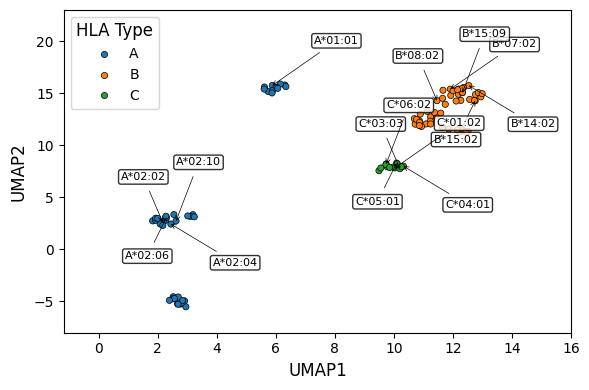

In [15]:
# Extract HLA type (first character: A, B, C, etc.)
umap_csv['hla_type'] = umap_csv['Allele'].str[0]

# Print number of unique alleles
print(f"Number of unique alleles: {umap_csv['Allele'].nunique()}")

# Set up the plot with larger size to give more space
plt.figure(figsize=(6, 4))  # Keeping your specified size

# Create scatter plot
ax = plt.gca()
sns.scatterplot(
    data=umap_csv,
    x='UMAP1',
    y='UMAP2',
    hue='hla_type',
    s=20,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# Group by HLA type and annotate 5 unique alleles for each type
hla_types = umap_csv['hla_type'].unique()
for hla_type in hla_types:
    # Get data for this HLA type
    hla_data = umap_csv[umap_csv['hla_type'] == hla_type]
    
    # Get unique alleles for this HLA type
    unique_alleles = hla_data.drop_duplicates('Allele')
    n_unique = len(unique_alleles)
    
    # If less than 5 unique alleles, use all available; otherwise select 5
    # Note: You had 12 here, changing back to 5 as per original request
    if n_unique <= 20:
        alleles_to_annotate = unique_alleles
    else:
        # Select 5 evenly spaced unique alleles
        step = n_unique // 20
        indices = [i * step for i in range(20)]
        alleles_to_annotate = unique_alleles.iloc[indices]
    
    # Define larger offsets to increase distance from points
    offsets = [
        (30, 30),   # Top-right (increased from 20)
        (-30, 30),  # Top-left (increased from -20)
        (30, -30),  #.Concurrent # Bottom-right (increased from 20)
        (-30, -30), # Bottom-left (increased from -20)
        (0, 40)     # Above (increased from 20)
    ]
    
    # Annotate each selected allele
    for idx, (index, row) in enumerate(alleles_to_annotate.iterrows()):
        if idx >= len(offsets):
            break
        plt.annotate(
            row['Allele'],
            (row['UMAP1'], row['UMAP2']),
            fontsize=8,
            xytext=offsets[idx],
            textcoords='offset points',
            arrowprops=dict(
                arrowstyle='->', 
                color='black', 
                lw=0.5, 
                shrinkA=5,  # Increased from 0 to move arrow start away from point
                shrinkB=0
            ),
            bbox=dict(boxstyle="round,pad=0.2", edgecolor="black", facecolor="white", alpha=0.8),
            clip_on=True
        )

# Get current axis limits and expand them slightly if needed
xlim = ax.get_xlim()
ylim = ax.get_ylim()
x_range = xlim[1] - xlim[0]
y_range = ylim[1] - ylim[0]
ax.set_xlim(xlim[0] - 0.2*x_range, xlim[1] + 0.2*x_range)
ax.set_ylim(-8, 23)

# Customize plot
# plt.title("UMAP of HLA Protein Embeddings (ESMC)", fontsize=14)
plt.xlabel("UMAP1", fontsize=12)
plt.ylabel("UMAP2", fontsize=12)
plt.legend(title="HLA Type", title_fontsize=12, fontsize=10)

# Ensure tight layout to prevent clipping
plt.tight_layout()

# out_dir = Path('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures_manuscript/')
# out_dir.mkdir(parents=True, exist_ok=True)      
# save_path = out_dir / f"fig1d.pdf"
# fig = plt.gcf()                                 # or keep a handle from plt.subplots()
# fig.savefig(save_path, dpi=300, bbox_inches="tight")
# plt.close(fig)   

# Show plot
plt.show()

In [16]:
from scipy.spatial.distance import cdist

# Step 1: Get coordinates of A0205
target = umap_csv[umap_csv['Allele'] == 'A0205']
if target.empty:
    print("❌ A0205 not found in data.")
else:
    target_coords = target[['UMAP1', 'UMAP2']].values

    # Step 2: Compare to all others (excluding A0205 itself)
    others = umap_csv[umap_csv['Allele'] != 'A0205'].copy()
    other_coords = others[['UMAP1', 'UMAP2']].values

    # Step 3: Compute distances
    dists = cdist(target_coords, other_coords)[0]  # get 1D array
    closest_idx = dists.argmin()
    closest_allele = others.iloc[closest_idx]

    print(f"✅ Closest allele to A0205 is {closest_allele['Allele']} at distance {dists[closest_idx]:.4f}")

    # Optional: annotate it on the plot
    plt.annotate(
        f"Closest to A0205:\n{closest_allele['Allele']}",
        (closest_allele['UMAP1'], closest_allele['UMAP2']),
        fontsize=9,
        xytext=(20, 20),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='red', lw=1),
        bbox=dict(boxstyle="round,pad=0.2", edgecolor="red", facecolor="white", alpha=0.8)
    )


❌ A0205 not found in data.


In [17]:
HLA = "HLAA0201"  # Example HLA allele

#########################################################
# FASTA Parser
#########################################################
def parse_fasta(file_path):
    sequences = []
    with open(file_path, 'r') as f:
        header = None
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append((header, seq))
                    seq = ""
                header = line[1:]
            else:
                seq += line
        if seq:
            sequences.append((header, seq))
    return sequences

#########################################################
# Load HLA Sequences
#########################################################
fasta_path = "/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/other/hla_sequences.fasta"
hla_data = parse_fasta(fasta_path)

hla_sequences = [
    seq for header, seq in hla_data
    if header.replace(':','').replace('*','') == HLA.replace("HLA", "")
]

In [18]:
# df_e = pd.read_csv('/global/scratch/users/sergiomar10/data/ESMC_Pretrain_09042025_perplexity/ESMMASK_epitope_FT_20_0.001_5e-05_AUG_1_HLAA1101_1_per_token_metrics.csv')

In [19]:
# df_e

In [20]:
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv',
                        sep=',', header=0)

/tmp/ipykernel_21188/989829955.py:1: DtypeWarning: Columns (6,12,13,14,27,28,29,30,34,35,36,37,38,39,40,41,42,45,46,47,48,49,50,51,52,53,54,55,56,57,65,66,67,68,72,73,74,75,76,79,80,81,82,83,84,85,86,87,88,89,92,95,100,101,102,103,104,105,106,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv',


In [21]:
IEDB_full[IEDB_full['MHC Restriction - Name'] == 'HLAA0201']['Epitope - Name'].unique()

array(['KLEDLERDL', 'ATLGFGAYM', 'LLDVTAAV', ..., 'FLMEPIYLV',
       'YLMEPIYLV', 'RLWEPIYLV'], dtype=object)

In [22]:
IEDB_full_subset = IEDB_full_subset[IEDB_full_subset['Assay - Qualitative Measurement'].str.contains('Positive')]


NameError: name 'IEDB_full_subset' is not defined

In [ ]:
IEDB_full_subset

,Assay ID - IEDB IRI,Reference - IEDB IRI,Reference - Type,Reference - PMID,Reference - Submission ID,Reference - Authors,Reference - Journal,Reference - Date,Reference - Title,Epitope - Epitope IRI,...,Antigen Presenting Cell - Source Tissue,Antigen Presenting Cell - Source Tissue IRI,Antigen Presenting Cell - Name,Antigen Presenting Cell - IRI,Antigen Presenting Cell - Culture Condition,MHC Restriction - Name,MHC Restriction - IRI,MHC Restriction - Evidence Code,MHC Restriction - Evidence IRI,MHC Restriction - Class


In [ ]:
import pandas as pd

In [ ]:
# Load Data S3: Training data for MHCflurry 2.0 BA predictor
training_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S3.csv')
print(f"Training data shape: {training_data.shape}")

# Filter for HLA-A*02:01
training_data_subset = training_data[
    (training_data['original_allele'].notna()) & 
    (training_data['original_allele'].str.contains('02:01'))
]
print(f"Training subset (HLA-A*02:01) shape: {training_data_subset.shape}")  # 9332 rows × 12 columns

Training data shape: (713069, 12)
Training subset (HLA-A*02:01) shape: (38504, 12)


In [ ]:
training_data_subset[training_data_subset['peptide'].str.contains('NIEES')]

,allele,peptide,measurement_value,measurement_inequality,measurement_type,measurement_kind,measurement_source,original_allele,fold_0,fold_1,fold_2,fold_3


findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Rounded MT Bold' not found.
findfont: Font family 'Arial Ro

Sequence logo saved as /clusterfs/nilah/sergio/RFdifussion/RFdiffusion/sequence_logo_struct_evo.png


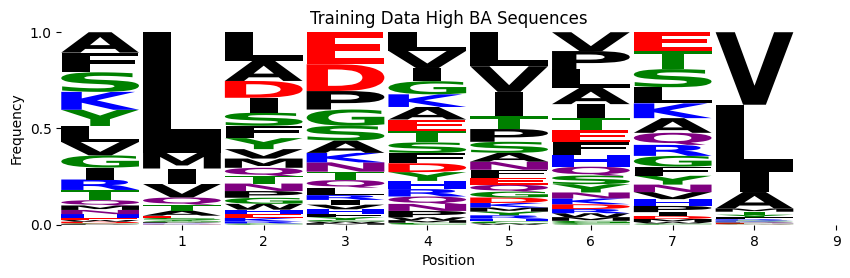

In [ ]:
import logomaker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming struct_evo is already loaded as a pandas DataFrame
# Filter for sequences of length 9 (if needed)
struct_evo = struct_evo[struct_evo['seq'].str.len() == 9]
training_data_subsetx = training_data_subset[(training_data_subset['peptide'].str.len() == 9) & (training_data_subsetx['measurement_value'] < 300)]
# Get the sequences
sequences = training_data_subsetx['peptide'].tolist()

# Create a list of amino acids (standard 20 amino acids)
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# Initialize a frequency matrix (9 positions x 20 amino acids)
num_positions = 9
freq_matrix = np.zeros((num_positions, len(amino_acids)))

# Populate the frequency matrix: count occurrences of each amino acid at each position
for seq in sequences:
    for i, aa in enumerate(seq):
        aa_index = amino_acids.index(aa)
        freq_matrix[i, aa_index] += 1

# Normalize the frequency matrix to get probabilities (frequencies sum to 1 at each position)
freq_matrix = freq_matrix / len(sequences)

# Create a DataFrame for logomaker
freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

# Generate the sequence logo
logo = logomaker.Logo(freq_df, color_scheme='chemistry', font_name='Arial Rounded MT Bold')

# Customize the logo
logo.style_spines(visible=False)
logo.ax.set_ylabel('Frequency')
logo.ax.set_xlabel('Position')
logo.ax.set_xticks(range(1, num_positions + 1))
logo.ax.set_yticks([0, 0.5, 1.0])
logo.ax.set_title('Training Data High BA Sequences')

# Save the logo to a file (since displaying might not work on a cluster without a GUI)
plt.savefig('/clusterfs/nilah/sergio/RFdifussion/RFdiffusion/sequence_logo_struct_evo.png', dpi=300, bbox_inches='tight')
print("Sequence logo saved as /clusterfs/nilah/sergio/RFdifussion/RFdiffusion/sequence_logo_struct_evo.png")

# If you're on a system with a GUI, you can uncomment the following to display the logo
# plt.show()

In [ ]:
# # Load Data S2: Monoallelic benchmark dataset with predictions
# test_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S2.csv')
# test_data_subset = test_data[test_data['hla'].str.contains('02:01')]
# unique_test_peptides = test_data_subset['peptide'].nunique()
# print(f"Unique peptides in test subset (HLA-A*02:01): {unique_test_peptides}")  # 5489

In [ ]:

# Assuming test_data is loaded elsewhere (e.g., from your benchmark)
# Check overlap with test_data
overlap_with_test = training_data_subset[
    training_data_subset['peptide'].isin(test_data['peptide'])
]
print(f"Training subset overlapping with test_data shape: {overlap_with_test.shape}")  # 2925 rows × 12 columns

non_overlap_with_test = training_data_subset[
    ~training_data_subset['peptide'].isin(test_data['peptide'])
]
print(f"Training subset not overlapping with test_data shape: {non_overlap_with_test.shape}")  # 6407 rows × 12 columns


Training subset overlapping with test_data shape: (9229, 12)
Training subset not overlapping with test_data shape: (29275, 12)


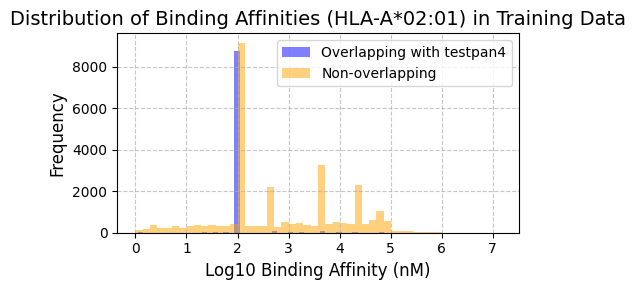

In [ ]:

# Visualize log10-transformed measurement values
plt.figure(figsize=(5, 3))
overlap_with_test['measurement_value'].apply(lambda x: np.log10(x + 1)).hist(bins=50, alpha=0.5, label='Overlapping with testpan4', color='blue')
non_overlap_with_test['measurement_value'].apply(lambda x: np.log10(x + 1)).hist(bins=50, alpha=0.5, label='Non-overlapping', color='orange')
plt.xlabel('Log10 Binding Affinity (nM)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Binding Affinities (HLA-A*02:01) in Training Data', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
training_data['measurement_technique'] = training_data['measurement_source'].str.split(' -', expand=True)[1] # value_counts()
training_data_subset = training_data[(training_data['measurement_technique'].str.contains('MHC/direct/')) & (training_data['measurement_technique'].notna())]
training_data_subset = training_data_subset[
    (training_data_subset['original_allele'].notna()) & 
    (training_data_subset['original_allele'].str.contains('02:01'))
]

### Loading Data from the MHC Flurry github repository by 

```bash

(cooltools) [sergiomar10@ln003 2.2.0]$ mhcflurry-downloads info
Environment variables
  MHCFLURRY_DATA_DIR                  [unset or empty]
  MHCFLURRY_DOWNLOADS_CURRENT_RELEASE [unset or empty]
  MHCFLURRY_DOWNLOADS_DIR             [unset or empty]
  MHCFLURRY_DEFAULT_CLASS1_MODELS     [unset or empty]

Configuration
  current release                     = 2.2.0                
  downloads dir                       = /global/home/users/sergiomar10/.local/share/mhcflurry/4/2.2.0 [exists]

DOWNLOAD NAME                             DOWNLOADED?   UP TO DATE?   URL                  
models_class1_pan                         NO                          https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_pan.selected.20200610.tar.bz2 
models_class1_presentation                YES           YES           https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_presentation.20200611.tar.bz2 
models_class1_processing                  NO                          https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_processing.selected.20200611.tar.bz2 
models_class1_pan_unselected              NO                          https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_pan.20200610.tar.bz2 
models_class1_pan_variants                NO                          https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_pan_variants.selected.20200610.tar.bz2 
data_evaluation                           YES           UNKNOWN       https://github.com/openvax/mhcflurry/releases/download/pre-2.0/data_evaluation.20200611.tar.bz2.part.aa + 2 more parts 
analysis_predictor_info                   NO                          https://github.com/openvax/mhcflurry/releases/download/pre-2.0/analysis_predictor_info.20200711.tar.bz2 
data_predictions                          NO                          https://github.com/openvax/mhcflurry/releases/download/pre-2.0/data_predictions.20200713.tar.bz2.part.aa + 11 more parts 
data_mass_spec_annotated                  NO                          https://github.com/openvax/mhcflurry/releases/download/1.6.0/data_mass_spec_annotated.20191226.tar.bz2 
data_references                           NO                          https://github.com/openvax/mhcflurry/releases/download/pre-1.4.0/data_references.20190927.tar.bz2 
data_iedb                                 NO                          https://github.com/openvax/mhcflurry/releases/download/pre-2.1/data_iedb.20231019.tar.bz2 
data_systemhcatlas                        NO                          http://github.com/openvax/mhcflurry/releases/download/pan-dev1/data_systemhcatlas.20190506.tar.bz2 
allele_sequences                          NO                          https://github.com/openvax/mhcflurry/releases/download/pre-2.1/allele_sequences.20231025.tar.bz2 
random_peptide_predictions                NO                          http://github.com/openvax/mhcflurry/releases/download/pan-dev1/random_peptide_predictions.20190506.tar.bz2 
data_published                            NO                          https://github.com/openvax/mhcflurry/releases/download/pre-1.7.0/data_published.20200501.tar.bz2 
data_curated                              YES           YES           https://github.com/openvax/mhcflurry/releases/download/pre-2.1/data_curated.20231023.tar.bz2 
models_class1                             YES           YES           http://github.com/openvax/mhcflurry/releases/download/pre-1.2/models_class1.20180225.tar.bz2 
models_class1_selected_no_mass_spec       NO                          http://github.com/openvax/mhcflurry/releases/download/pre-1.2/models_class1_selected_no_mass_spec.20180225.tar.bz2 
models_class1_unselected                  NO                          http://github.com/openvax/mhcflurry/releases/download/pre-1.2/models_class1_unselected.20180221.tar.bz2 
models_class1_trained_with_mass_spec      NO                          http://github.com/openvax/mhcflurry/releases/download/pre-1.2.1/models_class1_trained_with_mass_spec.20180228.tar.bz2 
models_class1_unselected_with_mass_spec   NO                          http://github.com/openvax/mhcflurry/releases/download/pre-1.2.1/models_class1_unselected_with_mass_spec.20180227.tar.bz2 
models_class1_minimal                     NO                          http://github.com/openvax/mhcflurry/releases/download/pre-1.2/models_class1_minimal.20180226.tar.bz2 
```


In [ ]:
mhc_flurry_training_data = pd.read_csv('/global/home/users/sergiomar10/.local/share/mhcflurry/4/2.2.0/data_curated/curated_training_data.affinity.csv')
mhc_eval_data_files = glob.glob('../../evaluation_data/benchmark.monoallelic.no_additional_ms.train_excluded.KESKIN_*.csv')

for allele in ['HLA-A0201']:

    allele = allele.replace('*', '').replace(':', '').replace('HLA-', '')
    mhc_eval_data_files = glob.glob(f'../../evaluation_data/*{allele}*.csv')
    mhc_flurry_training_data_subset = mhc_flurry_training_data[mhc_flurry_training_data['allele'].str.contains(allele[0] + '*' + allele[1:3] + ':' + allele[3:])]
    
    if len(mhc_eval_data_files) > 0:
            
        mhc_flurry_eval_data = pd.read_csv(mhc_eval_data_files[0]).drop_duplicates('peptide')
        eval_allele_peptides = mhc_flurry_eval_data['peptide'].unique()

        print(allele, mhc_flurry_training_data_subset[mhc_flurry_training_data_subset['peptide'].isin(eval_allele_peptides)]['peptide'].nunique())
        print('Not in training data:', len(set(eval_allele_peptides) - set(mhc_flurry_training_data_subset['peptide'].unique())))

A0201 0
Not in training data: 29375


In [ ]:
iedb_complete = pd.read_csv('/clusterfs/nilah/sergio/iedb_sql_epitopes/HLA-A0201_sql.csv', header = None)
iedb_complete.columns = ['HLA','peptide','BA','Qual','Literature','Submission']
iedb_complete

IEDB_sql = pd.read_csv('/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAA0201_final.csv', header=None)
IEDB_sql.columns = ['peptide', 'ref_ID', 'submissionID', 'Epitope_ID','protein_origin', 'ID_SOURCE', "SOURCE_ORGANISM", "IC50_nM", "DESCRIPTION_BINDING", "Year_submission"]
IEDB_sql.head(2)

IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'].astype(str)
IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'].str.replace('\\N', '0', regex=False)
IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'].astype('float')
IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'] + 1
IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'].apply(np.log10)

IEDB_sql['Year_submission'] = IEDB_sql['Year_submission'].astype(str)
IEDB_sql['Year_submission'] = IEDB_sql['Year_submission'].str.replace('\\N', '0', regex=False)
IEDB_sql['Year_submission'] = IEDB_sql['Year_submission'].astype(int)

In [ ]:
iedb_complete['BA'] = iedb_complete['BA'].astype(str)
iedb_complete['BA'] = iedb_complete['BA'].str.replace('\\N', '0', regex=False)
iedb_complete['BA'] = iedb_complete['BA'].astype('float')
iedb_complete['BA'] = iedb_complete['BA'] + 1
iedb_complete['BA'] = iedb_complete['BA'].apply(np.log10)

iedb_complete['Submission'] = iedb_complete['Submission'].astype(str)
iedb_complete['Submission'] = iedb_complete['Submission'].str.replace('\\N', '0', regex=False)
iedb_complete['Submission'] = iedb_complete['Submission'].astype(int)

In [ ]:
mhc_f_test = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry/HLAA0201_mhc_flurry.csv')
mhc_f_test.head(2)

,allele,peptide,mhcflurry_affinity,mhcflurry_affinity_percentile,mhcflurry_processing_score,mhcflurry_presentation_score,mhcflurry_presentation_percentile
0,HLAA0201,RAKLLGAEEK,27739.021138,28.874250,0.044665,0.004254,62.744674
1,HLAA0201,GRAKLLGAEEK,26034.732016,22.627125,0.151088,0.006578,37.359049


In [ ]:
Counter(iedb_complete['Qual'])

Counter({'Negative': 10373,
         'Positive': 6188,
         'Positive-High': 5221,
         'Positive-Low': 3692,
         'Positive-Intermediate': 3488})

In [ ]:
mhc_flurry_eval_data

,protein_accession,peptide,sample_id,n_flank,c_flank,hit,hla,no_additional_ms_affinity
0,Q9Y289,SIMDYVVFV,KESKIN_A0201,PLSPTSGTSVGMSTF,LLLVLSLAIGLYHAC,1,HLA-A*02:01,7.368309
1,F8W9P4,ALLICLPEV,KESKIN_A0201,PTGTVRSNPNTDSAA,APHPVYYPALEKLPG,1,HLA-A*02:01,13.478477
2,Q9Y3M8,QLLGGVRAV,KESKIN_A0201,GMCTLVSLSVEHEEA,VMDSQYLIEPCGSGK,1,HLA-A*02:01,29.391562
3,A0A2R8YG21,RTIEYLEEV,KESKIN_A0201,QLVEPLGPGLKPPEE,AITFAKGLADKKISP,1,HLA-A*02:01,12.701526
4,C9JSR4,ALSDIFQAV,KESKIN_A0201,RNFHPFAELPEPQQT,LFDDELLMVLEPVVS,1,HLA-A*02:01,8.288443
...,...,...,...,...,...,...,...,...
29408,A0A087WY96,YRPGPWMKYSW,KESKIN_A0201,YGGDNLYDGIEDMIG,AVITPVLCVGCFIFS,0,HLA-A*02:01,32511.993136
29409,Q9C035,VDVSKKTAWIL,KESKIN_A0201,ILGSQSITSGKHYWE,GVCAGFQPDAMCNIE,0,HLA-A*02:01,31067.283758
29410,A0A087WW06,QAKAYRGLGNG,KESKIN_A0201,EQYLSVAQSLNRMQD,HRAMGSLQQALVCFE,0,HLA-A*02:01,33896.975143
29411,P36776,YLLQEQLKIIK,KESKIN_A0201,LGREVEEKIKQTHRK,KELGLEKDDKDAIEE,0,HLA-A*02:01,13110.146391


In [ ]:
training_data_subset[training_data_subset['measurement_type'] == 'quantitative'].shape

(2140, 13)

In [ ]:
training_data_subset[training_data_subset['measurement_type'] == 'qualitative'].shape

(4495, 13)

In [ ]:
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/mhc_ligand_table_export_1727815227.tsv', sep = '\t', header = 0)
IEDB_full.head()

/tmp/ipykernel_908848/1962146925.py:1: DtypeWarning: Columns (6,12,13,14,19,20,21,22,23,24,25,26,27,28,29,30,34,35,36,37,38,39,40,41,42,45,46,47,48,49,50,51,52,53,54,55,56,57,60,61,62,63,64,65,66,67,68,70,71,72,73,74,75,76,79,80,81,82,83,84,85,86,87,88,89,92,95,100,101,102,103,104,105,106,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/mhc_ligand_table_export_1727815227.tsv', sep = '\t', header = 0)


,Assay ID - IEDB IRI,Reference - IEDB IRI,Reference - Type,Reference - PMID,Reference - Submission ID,Reference - Authors,Reference - Journal,Reference - Date,Reference - Title,Epitope - Epitope IRI,...,Antigen Presenting Cell - Source Tissue,Antigen Presenting Cell - Source Tissue IRI,Antigen Presenting Cell - Name,Antigen Presenting Cell - IRI,Antigen Presenting Cell - Culture Condition,MHC Restriction - Name,MHC Restriction - IRI,MHC Restriction - Evidence Code,MHC Restriction - Evidence IRI,MHC Restriction - Class
0,http://www.iedb.org/assay/26,http://www.iedb.org/reference/274,Literature,15448372.0,NaN,Yi-Hsiang Huang; Mi-Hua Tao; Cheng-Po Hu; Wan-...,J Gen Virol,2004,Identification of novel HLA-A*0201-restricted ...,http://www.iedb.org/epitope/31803,...,NaN,NaN,NaN,NaN,NaN,HLA-A*02:01,http://purl.obolibrary.org/obo/MRO_0001007,NaN,NaN,I
1,http://www.iedb.org/assay/115,http://www.iedb.org/reference/299,Literature,15140958.0,NaN,Yue-Dan Wang; Wan-Yee Fion Sin; Guo-Bing Xu; H...,J Virol,2004,T-cell epitopes in severe acute respiratory sy...,http://www.iedb.org/epitope/36724,...,NaN,NaN,NaN,NaN,NaN,HLA-A2,http://purl.obolibrary.org/obo/MRO_0001530,NaN,NaN,I
2,http://www.iedb.org/assay/143,http://www.iedb.org/reference/304,Literature,15102821.0,NaN,Alberto Diaz-Quiñonez; Natalia Martin-Orozco; ...,Infect Immun,2004,Two Salmonella OmpC K(b)-restricted epitopes f...,http://www.iedb.org/epitope/66114,...,NaN,NaN,NaN,NaN,NaN,H2-Kb,http://purl.obolibrary.org/obo/MRO_0000991,NaN,NaN,I
3,http://www.iedb.org/assay/144,http://www.iedb.org/reference/304,Literature,15102821.0,NaN,Alberto Diaz-Quiñonez; Natalia Martin-Orozco; ...,Infect Immun,2004,Two Salmonella OmpC K(b)-restricted epitopes f...,http://www.iedb.org/epitope/55063,...,NaN,NaN,NaN,NaN,NaN,H2-Kb,http://purl.obolibrary.org/obo/MRO_0000991,NaN,NaN,I
4,http://www.iedb.org/assay/247,http://www.iedb.org/reference/329,Literature,15104671.0,NaN,C Sylvester-Hvid; M Nielsen; K Lamberth; G Rød...,Tissue Antigens,2004,"SARS CTL vaccine candidates; HLA supertype-, g...",http://www.iedb.org/epitope/14829,...,NaN,NaN,NaN,NaN,NaN,HLA-A*03:01,http://purl.obolibrary.org/obo/MRO_0001026,NaN,NaN,I


In [ ]:
len(set(IEDB_full['Epitope - Name']).intersection(set(test_data['peptide'])))

242755

In [ ]:
len(set(IEDB_full['Epitope - Name']))

881858

In [ ]:
len(set(test_data['peptide']))

8537960

In [ ]:
test_data['hla'].nunique()

92

In [ ]:
IEDB_full['MHC Restriction - Name'] = IEDB_full['MHC Restriction - Name'].str.replace('*', '').str.replace(':', '').str.replace('-', '')

In [ ]:
IEDB_full_for_training = IEDB_full[IEDB_full['MHC Restriction - Name'].isin(IEDB_data['HLA'].unique())]

In [ ]:
IEDB_full_for_training.to_csv('/global/scratch/users/sergiomar10/ESMCBA/IEDB_subseted_HLA_w_BA_full_for_training.csv', index = False)

In [ ]:
IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == 'HLA-A*02:01']

In [ ]:
IEDB_full['peptide'] = IEDB_full['Epitope - Name']

In [ ]:
IEDB_full['Assay - Qualitative Measurement'].value_counts()

Assay - Qualitative Measurement
Positive                 2855977
Negative                  122869
Positive-High              31855
Positive-Low               29579
Positive-Intermediate      24044
Name: count, dtype: int64

In [ ]:
IEDB_full_subset = IEDB_full[['Assay - Qualitative Measurement', 'peptide','MHC Restriction - Name']]

In [ ]:
IEDB_full_subset_filtered_out_MHC = IEDB_full_subset[~(IEDB_full_subset['peptide'].isin(training_data['peptide'].unique()))]

In [ ]:
IEDB_full_subset_filtered_out_MHC = IEDB_full_subset_filtered_out_MHC.drop_duplicates(['peptide','MHC Restriction - Name'])

In [ ]:
IEDB_full_subset_filtered_out_MHC.to_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/IEDB_full_subset_filtered_out_MHCFlurry.csv', index = False)

In [ ]:
IEDB_full_subset_filtered_out_MHC[(IEDB_full_subset_filtered_out_MHC['MHC Restriction - Name'] == 'HLA-A*02:01') & ~(IEDB_full_subset_filtered_out_MHC['peptide'].isin(IEDB_sql['peptide'].unique()))]

,Assay - Qualitative Measurement,peptide,MHC Restriction - Name
638,Positive,GILGFVFTL + OTH(L9),HLA-A*02:01
6628,Positive,LGEFYNQM,HLA-A*02:01
6629,Positive,KLGEFYNQ,HLA-A*02:01
6855,Positive,"GLLGFVFTL + MCM(G1, L2)",HLA-A*02:01
7502,Positive,LTKGILSFVFTLTVPSERG,HLA-A*02:01
...,...,...,...
3064314,Positive,FLWEPIYLV,HLA-A*02:01
3064315,Positive,RLMEPIWEV,HLA-A*02:01
3064316,Positive,FLMEPIYLV,HLA-A*02:01
3064317,Positive,YLMEPIYLV,HLA-A*02:01


openvax/mhcflurry | curated_training_data: 19554 unique peptides (using 'peptide' column)
openvax/mhcflurry | benchmark: 29375 unique peptides (using 'peptide' column)
ODonnell 2020 | Test (Data S2): 81257 unique peptides (using 'peptide' column)
ODonnell 2020 | Training (Data S3): 5894 unique peptides (using 'peptide' column)
2025 IEDB | Real Data: 80777 unique peptides (using 'peptide' column)
2025 IEDB BA: 11605 unique peptides (using 'peptide' column)
2025 IEDB Complete: 17905 unique peptides (using 'peptide' column)
2020 IEDB: 464 unique peptides (using 'peptide' column)


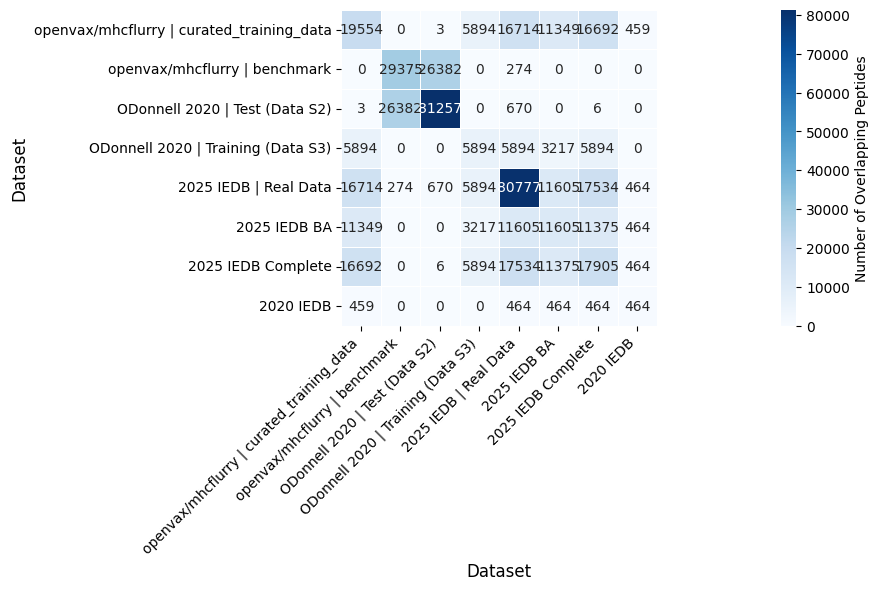

In [ ]:
from itertools import combinations

# Assuming these DataFrames are loaded; adjust column names if needed
datasets = {
    'openvax/mhcflurry | curated_training_data': mhc_flurry_training_data_subset,
    'openvax/mhcflurry | benchmark': mhc_flurry_eval_data,
    'ODonnell 2020 | Test (Data S2)': test_data_subset,
    'ODonnell 2020 | Training (Data S3)': training_data_subset,
    '2025 IEDB | Real Data': IEDB_full_subset,
    '2025 IEDB BA' : IEDB_sql,
    '2025 IEDB Complete': iedb_complete,
    '2020 IEDB': mhc_f_test
}

# Function to safely extract unique peptides
def get_unique_peptides(df, name):
    if df is None:
        print(f"{name} is None")
        return set()
    if not isinstance(df, pd.DataFrame):
        print(f"{name} is not a DataFrame, type: {type(df)}")
        if isinstance(df, (list, np.ndarray, pd.Series)):
            return set(pd.Series(df).unique())
        return set()
    # Try 'peptide' first, then 'sequence' as fallback
    column = 'peptide' if 'peptide' in df.columns else 'sequence' if 'sequence' in df.columns else None
    if column:
        uniques = df[column].unique()
        print(f"{name}: {len(uniques)} unique peptides (using '{column}' column)")
        return set(uniques)
    else:
        print(f"{name}: No 'peptide' or 'sequence' column found. Columns: {list(df.columns)}")
        return set()

# Extract unique peptides with error handling
peptide_sets = {
    name: get_unique_peptides(df, name)
    for name, df in datasets.items()
}

# Remove empty sets (if any dataset failed to provide peptides)
peptide_sets = {k: v for k, v in peptide_sets.items() if v}
if not peptide_sets:
    raise ValueError("No valid peptide sets to compare")

# Compute overlap matrix
dataset_names = list(peptide_sets.keys())
n = len(dataset_names)
overlap_matrix = np.zeros((n, n), dtype=int)

for i, name1 in enumerate(dataset_names):
    for j, name2 in enumerate(dataset_names):
        if i == j:
            overlap_matrix[i, j] = len(peptide_sets[name1])  # Diagonal: total unique peptides
        else:
            overlap_matrix[i, j] = len(peptide_sets[name1] & peptide_sets[name2])  # Off-diagonal: overlap

# Create DataFrame for the matrix
overlap_df = pd.DataFrame(overlap_matrix, index=dataset_names, columns=dataset_names)
# print("\nPairwise Overlap Matrix:")
# print(overlap_df)

# Visualization: Heatmap of overlaps
plt.figure(figsize=(25, 6))
sns.heatmap(overlap_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Overlapping Peptides'},
            square=True, linewidths=0.5, annot_kws={'fontsize': 10})
# plt.title('Peptide Overlap Between Datasets', fontsize=14, pad=10)
plt.xlabel('Dataset', fontsize=12)
plt.ylabel('Dataset', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
# plt.savefig('peptide_overlap_heatmap.png', dpi=300)
plt.show()

In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# test_data_subset.head(40)

In [ ]:
# import os

# # Define the datasets dictionary
# datasets = {
#     'REPO_curated_training_data': mhc_flurry_training_data_subset,
#     'REPO_benchmark': mhc_flurry_eval_data,
#     'Test_Data_S2': test_data_subset,
#     'Training_Data_S3': training_data_subset,
#     'IEDB_BA': IEDB_sql,
#     'IEDB_Complete': iedb_complete,
#     '2021_IEDB': mhc_f_test
# }

# # Create the directory for SLURM scripts (do this once)
# sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/EVALS_DATASETS'
# os.makedirs(sh_file_dir, exist_ok=True)

# # Define a placeholder for the second command if needed
# esmcba_cmd = "echo 'ESMCBA command not defined'"  # Replace with the actual command if available

# # Loop over each dataset to create a SLURM script
# for name, data in datasets.items():
#     # Get the unique peptides and ensure they are strings
#     cleaned_peptides = [str(p) for p in data['peptide'].unique()]
#     peptides_str = ' '.join(cleaned_peptides)
    
#     allele_clean = 'HLAA0201'
#     run_id = f"EVAL_MHCFLURRY_FUSIONS_{name}"
    
#     # Define the mhcflurry command
#     mhcflurry_cmd = (
#         f"mhcflurry-predict --alleles {allele_clean} "
#         f"--peptides {peptides_str} "
#         f"--out /global/scratch/users/sergiomar10/slurm_jobs/EVALS_DATASETS/output/{name}_mhc_flurry.csv"
#     )
    
#     # Set the file path for the SLURM script
#     sh_filepath = os.path.join(sh_file_dir, f"{run_id}.sh")
    
#     # Write the SLURM script
#     with open(sh_filepath, 'w') as sh_file:
#         sh_file.write('#!/bin/bash\n')
#         sh_file.write('#SBATCH --account=co_nilah\n')
#         sh_file.write('#SBATCH --partition=savio3_gpu\n')
#         sh_file.write('#SBATCH --qos=savio_lowprio\n')
#         sh_file.write('#SBATCH --cpus-per-task=4\n')
#         sh_file.write('#SBATCH --gres=gpu:1\n')
#         sh_file.write('#SBATCH --time=00:40:00\n')
#         sh_file.write(f'#SBATCH --job-name={run_id}\n')
#         sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.out\n')
#         sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.err\n')
#         sh_file.write('\n')
#         sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
#         sh_file.write('conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools\n')
#         sh_file.write('\n')
#         sh_file.write(f"{mhcflurry_cmd}\n")
#         sh_file.write('\n')
    
#     # Make the script executable
#     os.chmod(sh_filepath, 0o755)
#     print(f"Created SLURM script: {sh_filepath}")


In [ ]:
datas3 = pd.read_csv('/global/scratch/users/sergiomar10/slurm_jobs/EVALS_DATASETS/output/DataS3.csv')
training_data_subset.drop_duplicates('peptide') 

,allele,peptide,measurement_value,measurement_inequality,measurement_type,measurement_kind,measurement_source,original_allele,fold_0,fold_1,fold_2,fold_3,measurement_technique
45289,HLA-A*02:01,AAAAEEEEE,5000.0,>,qualitative,affinity,Grubeck-Loebenstein - cellular MHC/direct/fluo...,HLA-A*02:01,True,True,True,True,cellular MHC/direct/fluorescence
45290,HLA-A*02:01,AAAAGWQTL,5000.0,<,qualitative,affinity,Wen - cellular MHC/direct/fluorescence,HLA-A*02:01,True,True,True,True,cellular MHC/direct/fluorescence
45295,HLA-A*02:01,AAAGDKLSL,500.0,<,qualitative,affinity,pez - cellular MHC/direct/fluorescence,HLA-A*02:01,True,True,True,True,cellular MHC/direct/fluorescence
45296,HLA-A*02:01,AAAGIGILTV,500.0,<,qualitative,affinity,McElwee - cellular MHC/direct/fluorescence,HLA-A*02:01,True,True,True,True,cellular MHC/direct/fluorescence
45312,HLA-A*02:01,AAASAIQGN,5000.0,>,qualitative,affinity,Maeurer - purified MHC/direct/fluorescence,HLA-A*02:01,True,True,True,True,purified MHC/direct/fluorescence
...,...,...,...,...,...,...,...,...,...,...,...,...,...
84791,HLA-A*02:01,YYLEKANKI,20000.0,>,quantitative,affinity,Buus - purified MHC/direct/fluorescence,HLA-A*02:01,True,True,True,True,purified MHC/direct/fluorescence
84798,HLA-A*02:01,YYQLCQHLK,20000.0,>,quantitative,affinity,Buus - purified MHC/direct/fluorescence,HLA-A*02:01,True,True,True,True,purified MHC/direct/fluorescence
84801,HLA-A*02:01,YYQSGLSIV,5000.0,>,qualitative,affinity,Maeurer - purified MHC/direct/fluorescence,HLA-A*02:01,True,True,True,True,purified MHC/direct/fluorescence
84804,HLA-A*02:01,YYTEQPIDL,5000.0,>,qualitative,affinity,Buus - purified MHC/direct/fluorescence,HLA-A*02:01,True,True,True,True,purified MHC/direct/fluorescence


In [ ]:
# Define the datasets dictionary
datasets = {
    'REPO_curated_training_data': mhc_flurry_training_data_subset,
    'REPO_benchmark': mhc_flurry_eval_data,
    'Test_Data_S2': test_data_subset,
    'Training_Data_S3': training_data_subset,
    # 'IEDB_BA': IEDB_sql,
    'IEDB_Complete': iedb_complete,
    # '2021_IEDB': mhc_f_test
}

In [ ]:
iedb_complete

,HLA,peptide,BA,Qual,Literature,Submission
0,HLA-A*02:01,RLQSLQTYV,2.78,Positive,Literature,2023
1,HLA-A*02:01,RLQSLQIYV,2.6,Positive,Literature,2023
2,HLA-A*02:01,RMFYNAPYL,\N,Positive,Literature,2016
3,HLA-A*02:01,NLVPMVATV,2.1,Positive,Literature,2015
4,HLA-A*02:01,NLVPMVATV,3.51,Positive,Literature,2015
...,...,...,...,...,...,...
28957,HLA-A*02:01,SLLMYITQV,57.6,Positive,Literature,2024
28958,HLA-A*02:01,TLGIVCPI,\N,Positive,Literature,2007
28959,HLA-A*02:01,QYIKANSKFIGITEGGGTLGIVCPI,\N,Positive,Literature,2007
28960,HLA-A*02:01,VLVGACGVGV,\N,Positive,Literature,2024


In [ ]:
iedb_complete[(iedb_complete['BA'].notna() ) & (iedb_complete['BA'] != 'HLA-A*02:01')] #.astype('float') #['BA'].hist()

,HLA,peptide,BA,Qual,Literature,Submission
0,HLA-A*02:01,RLQSLQTYV,2.78,Positive,Literature,2023
1,HLA-A*02:01,RLQSLQIYV,2.6,Positive,Literature,2023
2,HLA-A*02:01,RMFYNAPYL,\N,Positive,Literature,2016
3,HLA-A*02:01,NLVPMVATV,2.1,Positive,Literature,2015
4,HLA-A*02:01,NLVPMVATV,3.51,Positive,Literature,2015
...,...,...,...,...,...,...
28957,HLA-A*02:01,SLLMYITQV,57.6,Positive,Literature,2024
28958,HLA-A*02:01,TLGIVCPI,\N,Positive,Literature,2007
28959,HLA-A*02:01,QYIKANSKFIGITEGGGTLGIVCPI,\N,Positive,Literature,2007
28960,HLA-A*02:01,VLVGACGVGV,\N,Positive,Literature,2024


In [ ]:
mhc_f_test = pd.read_csv('/global/scratch/users/sergiomar10/slurm_jobs/EVALS_DATASETS/output/Training_Data_S3_mhc_flurry.csv')

predictions = pd.merge(mhc_f_test[['peptide', 'mhcflurry_affinity']], training_data_subset[['peptide', 'measurement_value']], on='peptide', how='inner')
predictions['measurement_value'].value_counts().head(10)

measurement_value
5000.0     2634
500.0      1538
20000.0    1313
100.0       194
1000.0      146
1.0          72
5.0          46
2.0          12
10.0         11
3.0           8
Name: count, dtype: int64

In [ ]:
predictions = predictions[predictions['measurement_value'] != 5000.0]
predictions = predictions[predictions['measurement_value'] != 500.0]
predictions = predictions[predictions['measurement_value'] != 20000.0]
predictions = predictions[predictions['measurement_value'] != 1000.0]
predictions = predictions[predictions['measurement_value'] != 100.0]


In [ ]:
predictions

,peptide,mhcflurry_affinity,measurement_value
18,AALEGLSGF,6598.908375,1900.0
32,AAYHPQQFI,2740.005993,555.1
37,ACMDGFEVV,443.897127,290.2
39,ADFKLFFRW,22759.009064,9293.0
123,AIIDYIAYM,25.359090,1.0
...,...,...,...
6593,YTPLNYSKF,10768.423337,5113.0
6599,YTYPIAHTA,28.742433,851.5
6603,YVDIIGLSV,43.650882,56.0
6613,YVPTEFWGF,4880.491921,11127.5


In [ ]:
predictions['mhcflurry_affinity'] = predictions['mhcflurry_affinity'].apply(np.log10)
predictions['measurement_value'] = predictions['measurement_value'].apply(np.log10)

In [ ]:
predictions['residulal'] = predictions['mhcflurry_affinity'] - predictions['measurement_value']

<Axes: xlabel='measurement_value', ylabel='residulal'>

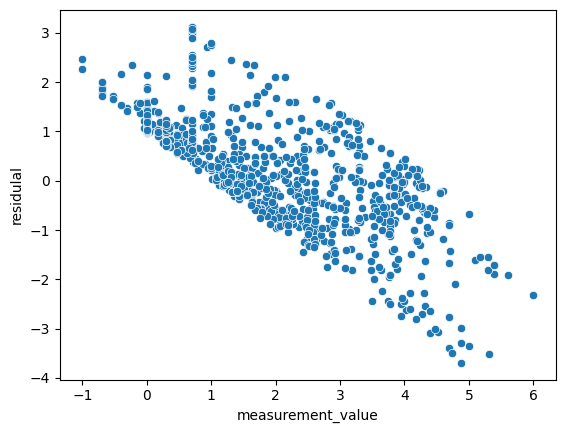

In [ ]:
sns.scatterplot(data = predictions, x = 'measurement_value', y= 'residulal')

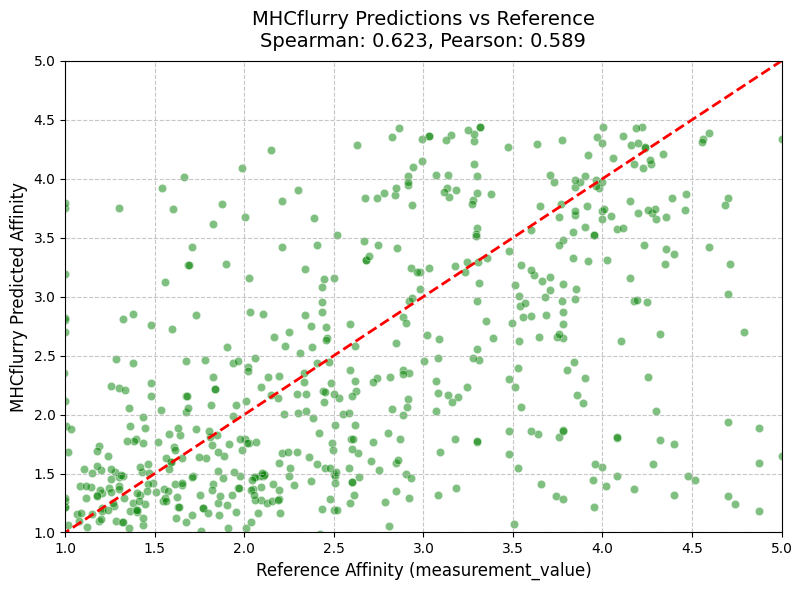

In [ ]:

def compute_metrics(reference, predicted, model_name):
    """Compute Spearman, Pearson correlations, and MSE between reference and predicted values."""
    spearman = spearmanr(reference, predicted)
    pearson = pearsonr(reference, predicted)
    mse = mean_squared_error(reference, predicted)
    return {
        'Model': model_name,
        'Spearman': spearman.correlation,
        'Pearson': pearson[0],
        'MSE': mse
    }

# Compute metrics for both models
reference = predictions['measurement_value']
metrics_mhcflurry = compute_metrics(reference, predictions['mhcflurry_affinity'], 'MHCflurry')

# Visualization 2: Scatter Plot for MHCflurry vs Reference
plt.figure(figsize=(8, 6))
sns.scatterplot(x='measurement_value', y='mhcflurry_affinity', data=predictions, alpha=0.5, color='green')
plt.plot([reference.min(), reference.max()], [reference.min(), reference.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel('Reference Affinity (measurement_value)', fontsize=12)
plt.ylabel('MHCflurry Predicted Affinity', fontsize=12)
plt.title(f'MHCflurry Predictions vs Reference\nSpearman: {metrics_mhcflurry["Spearman"]:.3f}, Pearson: {metrics_mhcflurry["Pearson"]:.3f}', 
          fontsize=14, pad=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xlim(1, 5)
plt.ylim(1, 5)
plt.show()

In [ ]:
mhc_f_test = pd.read_csv('/global/scratch/users/sergiomar10/slurm_jobs/EVALS_DATASETS/output/Test_Data_S2_mhc_flurry.csv')

predictions = pd.merge(mhc_f_test[['peptide', 'mhcflurry_affinity']], test_data_subset[['peptide', 'mhcflurry2.mono_held_out.ba']], on='peptide', how='inner')
# predictions['mhcflurry2.mono_held_out.ba'].value_counts().head(10)
predictions['mhcflurry_affinity'] = predictions['mhcflurry_affinity'].apply(np.log10)
predictions['mhcflurry2.mono_held_out.ba'] = predictions['mhcflurry2.mono_held_out.ba'].apply(np.log10)

<Axes: xlabel='hit', ylabel='mhcflurry2.mono_held_out.ba'>

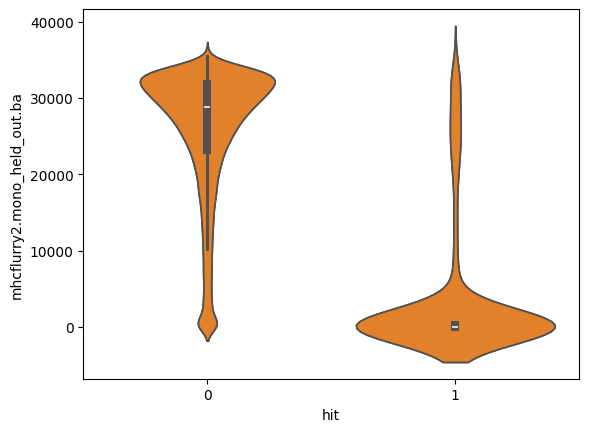

In [ ]:
sns.violinplot(data = test_data_subset, x= 'hit', y = 'mhcflurry2.mono_held_out.ba')
sns.violinplot(data = test_data_subset, x= 'hit', y = 'mhcflurry2.mono_held_out.ba')

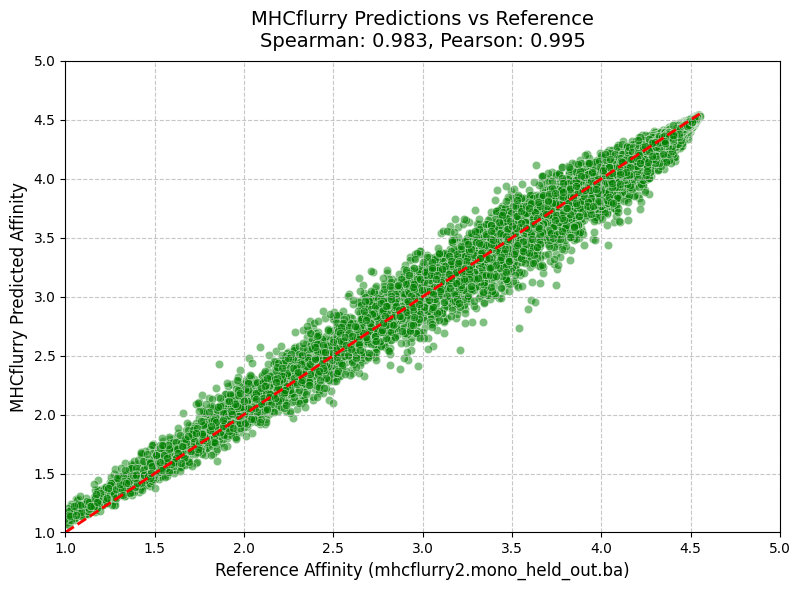

In [ ]:

def compute_metrics(reference, predicted, model_name):
    """Compute Spearman, Pearson correlations, and MSE between reference and predicted values."""
    spearman = spearmanr(reference, predicted)
    pearson = pearsonr(reference, predicted)
    mse = mean_squared_error(reference, predicted)
    return {
        'Model': model_name,
        'Spearman': spearman.correlation,
        'Pearson': pearson[0],
        'MSE': mse
    }

# Compute metrics for both models
reference = predictions['mhcflurry2.mono_held_out.ba']
metrics_mhcflurry = compute_metrics(reference, predictions['mhcflurry_affinity'], 'MHCflurry')

# Visualization 2: Scatter Plot for MHCflurry vs Reference
plt.figure(figsize=(8, 6))
sns.scatterplot(x='mhcflurry2.mono_held_out.ba', y='mhcflurry_affinity', data=predictions, alpha=0.5, color='green')
plt.plot([reference.min(), reference.max()], [reference.min(), reference.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel('Reference Affinity (mhcflurry2.mono_held_out.ba)', fontsize=12)
plt.ylabel('MHCflurry Predicted Affinity', fontsize=12)
plt.title(f'MHCflurry Predictions vs Reference\nSpearman: {metrics_mhcflurry["Spearman"]:.3f}, Pearson: {metrics_mhcflurry["Pearson"]:.3f}', 
          fontsize=14, pad=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xlim(1, 5)
plt.ylim(1, 5)
plt.show()

In [ ]:
mhc_f_test = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry/HLA-A0201_mhc_flurry.csv')
mhc_f_test.head(2)

,allele,peptide,mhcflurry_affinity,mhcflurry_affinity_percentile,mhcflurry_processing_score,mhcflurry_presentation_score,mhcflurry_presentation_percentile
0,HLA-A0201,GILGFVFTL,19.955124,0.09700,0.213533,0.897678,0.125516
1,HLA-A0201,LLFAKFSFLI,67.634138,0.45675,0.026809,0.580634,0.653478


In [ ]:
IEDB_sql = pd.read_csv('/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAA0201_final.csv', header=None)
IEDB_sql.columns = ['peptide', 'ref_ID', 'submissionID', 'Epitope_ID','protein_origin', 'ID_SOURCE', "SOURCE_ORGANISM", "IC50_nM", "DESCRIPTION_BINDING", "Year_submission"]
IEDB_sql.head(2)

,peptide,ref_ID,submissionID,Epitope_ID,protein_origin,ID_SOURCE,SOURCE_ORGANISM,IC50_nM,DESCRIPTION_BINDING,Year_submission
0,KVCGSNLLSI,33961,631987,AAA59565.1,myelin proteolipid protein,9606,Homo sapiens (human),4545,Positive-Low,1997
1,KTPLYYLSGT,33817,28765,AAO89309.1,ankyrin-like protein,10254,Vaccinia virus WR (Vaccinia virus (strain WR)),45000,Negative,\N


In [ ]:
IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'].astype(str)
IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'].str.replace('\\N', '0', regex=False)
IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'].astype('float')
IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'] + 1
IEDB_sql['IC50_nM'] = IEDB_sql['IC50_nM'].apply(np.log10)

IEDB_sql['Year_submission'] = IEDB_sql['Year_submission'].astype(str)
IEDB_sql['Year_submission'] = IEDB_sql['Year_submission'].str.replace('\\N', '0', regex=False)
IEDB_sql['Year_submission'] = IEDB_sql['Year_submission'].astype(int)

In [ ]:
predictions = pd.merge(mhc_f_test[['peptide', 'mhcflurry_affinity']], IEDB_sql[['peptide', 'IC50_nM']], on='peptide', how='inner')
predictions['mhcflurry_affinity'] = predictions['mhcflurry_affinity'].apply(lambda x: np.log10(x + 1))
# predictions['IC50_nM'] = predictions['IC50_nM'].apply(lambda x: np.log10(x + 1))

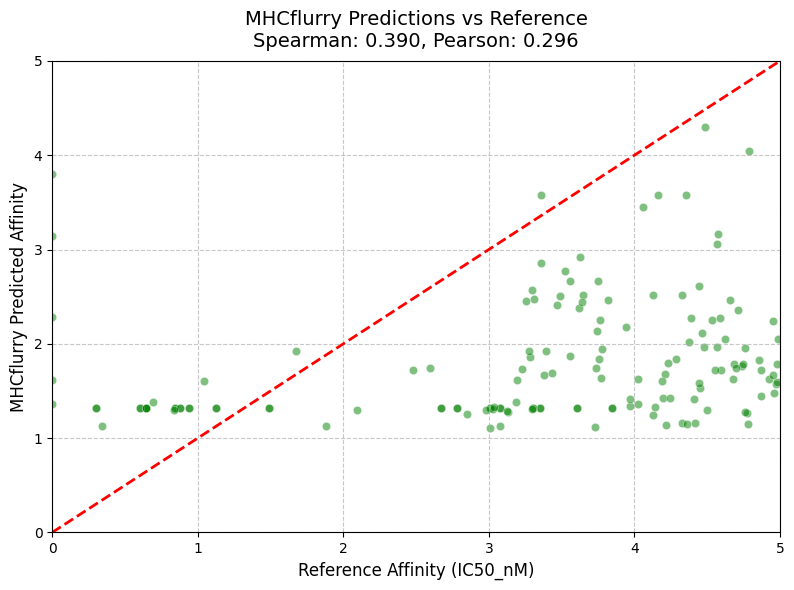

In [ ]:
def compute_metrics(reference, predicted, model_name):
    """Compute Spearman, Pearson correlations, and MSE between reference and predicted values."""
    spearman = spearmanr(reference, predicted)
    pearson = pearsonr(reference, predicted)
    mse = mean_squared_error(reference, predicted)
    return {
        'Model': model_name,
        'Spearman': spearman.correlation,
        'Pearson': pearson[0],
        'MSE': mse
    }

# Compute metrics for both models
reference = predictions['IC50_nM']
metrics_mhcflurry = compute_metrics(reference, predictions['mhcflurry_affinity'], 'MHCflurry')

# Visualization 2: Scatter Plot for MHCflurry vs Reference
plt.figure(figsize=(8, 6))
sns.scatterplot(x='IC50_nM', y='mhcflurry_affinity', data=predictions, alpha=0.5, color='green')
plt.plot([reference.min(), reference.max()], [reference.min(), reference.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel('Reference Affinity (IC50_nM)', fontsize=12)
plt.ylabel('MHCflurry Predicted Affinity', fontsize=12)
plt.title(f'MHCflurry Predictions vs Reference\nSpearman: {metrics_mhcflurry["Spearman"]:.3f}, Pearson: {metrics_mhcflurry["Pearson"]:.3f}', 
          fontsize=14, pad=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.show()

In [ ]:
finetuned = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/MSE_loss/FinetunedESM/evaluation_HLAB4402_mhcflurry_unique.csv')
mhc_f = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry/HLAB4402_mhc_flurry.csv')
netmhc = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/MSE_loss/NETMHCSPAN4/HLA-A0301_netmhc.xls', sep = '\t', header = 1)

mhc_eval_data_files = glob.glob(f'../../evaluation_data/*B4402*.csv')
eval_data = pd.read_csv(mhc_eval_data_files[0]).drop_duplicates('peptide')
eval_data = eval_data[['peptide','no_additional_ms_affinity']]

finetuned = pd.merge(left = finetuned,right =  mhc_f[['peptide','mhcflurry_affinity']], left_on='sequence', right_on='peptide', how='left')
finetuned = pd.merge(left = finetuned,right =  eval_data, left_on='sequence', right_on='peptide', how='left')

finetuned['mhcflurry_affinity'] = finetuned['mhcflurry_affinity'].apply(lambda x: np.log10(x))
finetuned['no_additional_ms_affinity'] = finetuned['no_additional_ms_affinity'].apply(lambda x: np.log10(x))

Performance Metrics:
                 Model  Spearman   Pearson       MSE
0  ESMCBA (Fine-tuned)  0.425693  0.545947  0.438204
1            MHCflurry  0.965328  0.993900  0.003284


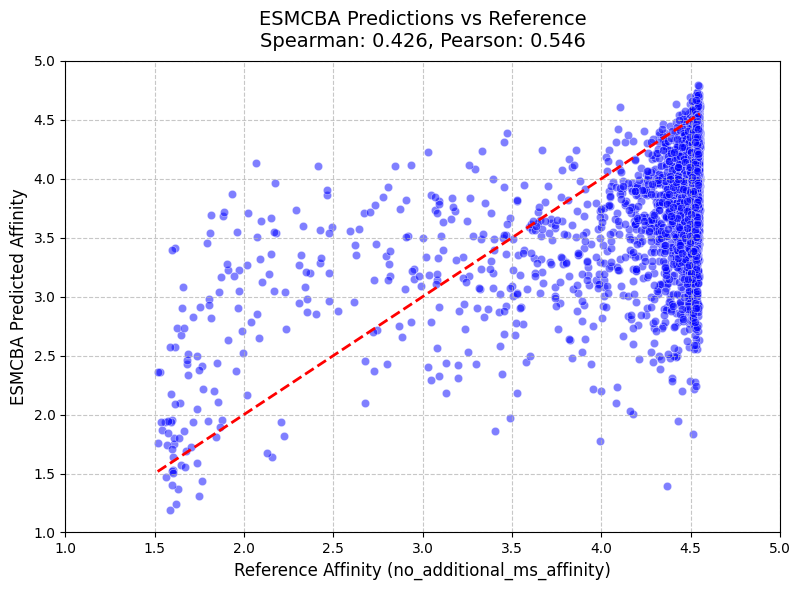

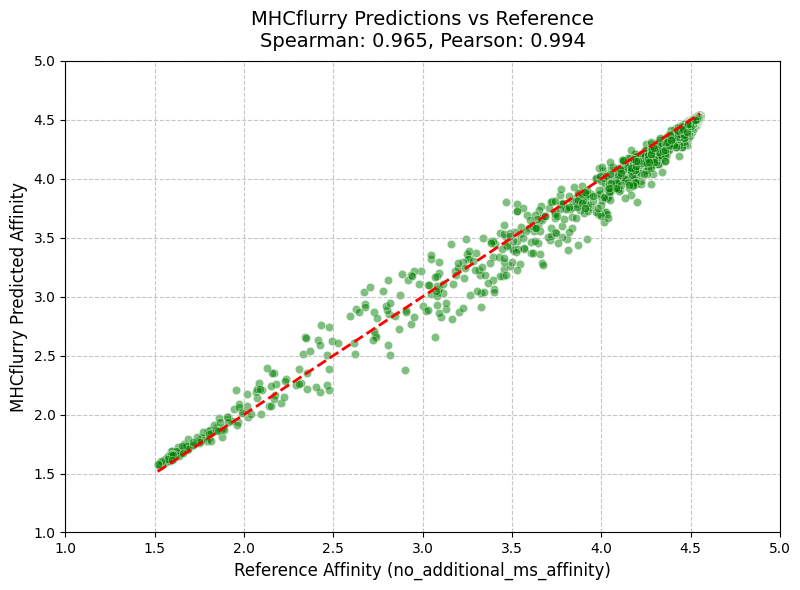

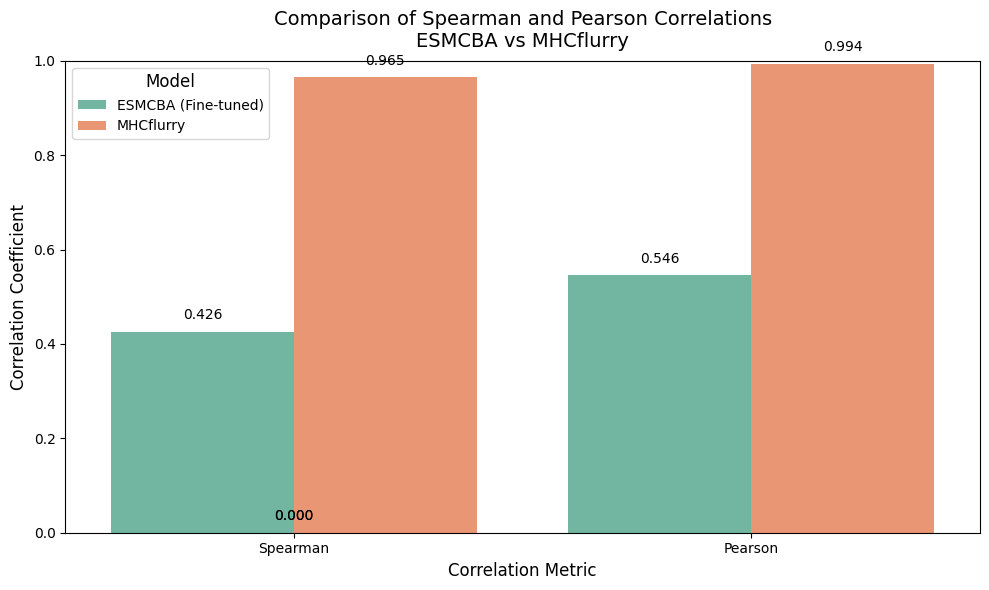

/tmp/ipykernel_390800/2720516345.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=metrics_df, palette='Set1')


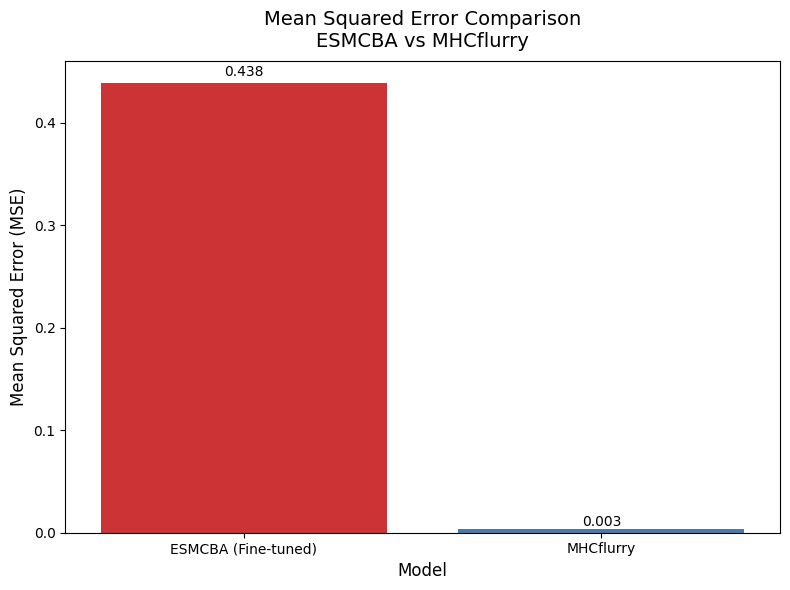

Plots saved: esmcba_vs_reference_scatter.png, mhcflurry_vs_reference_scatter.png, correlation_barplot.png, mse_barplot.png


In [ ]:
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error

# Assuming 'finetuned' DataFrame is already loaded with required columns
# Example structure: finetuned = pd.read_csv('your_data.csv')

def compute_metrics(reference, predicted, model_name):
    """Compute Spearman, Pearson correlations, and MSE between reference and predicted values."""
    spearman = spearmanr(reference, predicted)
    pearson = pearsonr(reference, predicted)
    mse = mean_squared_error(reference, predicted)
    return {
        'Model': model_name,
        'Spearman': spearman.correlation,
        'Pearson': pearson[0],
        'MSE': mse
    }

# Compute metrics for both models
reference = finetuned['no_additional_ms_affinity']
metrics_esmcba = compute_metrics(reference, finetuned['prediction'], 'ESMCBA (Fine-tuned)')
metrics_mhcflurry = compute_metrics(reference, finetuned['mhcflurry_affinity'], 'MHCflurry')

# Combine metrics into a DataFrame
metrics_df = pd.DataFrame([metrics_esmcba, metrics_mhcflurry])
print("Performance Metrics:")
print(metrics_df)

# Visualization 1: Scatter Plot for ESMCBA vs Reference
plt.figure(figsize=(8, 6))
sns.scatterplot(x='no_additional_ms_affinity', y='prediction', data=finetuned, alpha=0.5, color='blue')
plt.plot([reference.min(), reference.max()], [reference.min(), reference.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel('Reference Affinity (no_additional_ms_affinity)', fontsize=12)
plt.ylabel('ESMCBA Predicted Affinity', fontsize=12)
plt.title(f'ESMCBA Predictions vs Reference\nSpearman: {metrics_esmcba["Spearman"]:.3f}, Pearson: {metrics_esmcba["Pearson"]:.3f}', 
          fontsize=14, pad=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xlim(1, 5)
plt.ylim(1, 5)
# plt.savefig('esmcba_vs_reference_scatter.png', dpi=300)
plt.show()

# Visualization 2: Scatter Plot for MHCflurry vs Reference
plt.figure(figsize=(8, 6))
sns.scatterplot(x='no_additional_ms_affinity', y='mhcflurry_affinity', data=finetuned, alpha=0.5, color='green')
plt.plot([reference.min(), reference.max()], [reference.min(), reference.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel('Reference Affinity (no_additional_ms_affinity)', fontsize=12)
plt.ylabel('MHCflurry Predicted Affinity', fontsize=12)
plt.title(f'MHCflurry Predictions vs Reference\nSpearman: {metrics_mhcflurry["Spearman"]:.3f}, Pearson: {metrics_mhcflurry["Pearson"]:.3f}', 
          fontsize=14, pad=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xlim(1, 5)
plt.ylim(1, 5)
# plt.savefig('mhcflurry_vs_reference_scatter.png', dpi=300)
plt.show()

# Visualization 3: Bar Plot for Spearman and Pearson Correlations
plt.figure(figsize=(10, 6))
metrics_melted = metrics_df.melt(id_vars=['Model'], value_vars=['Spearman', 'Pearson'], 
                                 var_name='Metric', value_name='Value')
sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_melted, palette='Set2')
plt.xlabel('Correlation Metric', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.title('Comparison of Spearman and Pearson Correlations\nESMCBA vs MHCflurry', fontsize=14, pad=10)
plt.ylim(0, 1)  # Assuming correlations are between 0 and 1
for i, bar in enumerate(plt.gca().patches):
    height = bar.get_height()
    plt.gca().text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.3f}', 
                   ha='center', va='bottom', fontsize=10)
plt.legend(title='Model', title_fontsize=12, fontsize=10)
plt.tight_layout()
# plt.savefig('correlation_barplot.png', dpi=300)
plt.show()

# Visualization 4: Bar Plot for MSE
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='MSE', data=metrics_df, palette='Set1')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Mean Squared Error Comparison\nESMCBA vs MHCflurry', fontsize=14, pad=10)
for i, bar in enumerate(plt.gca().patches):
    height = bar.get_height()
    plt.gca().text(bar.get_x() + bar.get_width() / 2, height + 0.01 * height, f'{height:.3f}', 
                   ha='center', va='bottom', fontsize=10)
plt.tight_layout()
# plt.savefig('mse_barplot.png', dpi=300)
plt.show()

print("Plots saved: esmcba_vs_reference_scatter.png, mhcflurry_vs_reference_scatter.png, "
      "correlation_barplot.png, mse_barplot.png")

In [ ]:
def classify(name):
    name_lower = name.lower()
    if 'virus' in name_lower:
        return 'virus'
    elif 'mycobacterium' in name_lower:
        return 'bacterium'
    else:
        return 'other'

# Get all matching CSV files in the folder (here limiting to first 10 for example)
file_list = glob.glob('/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_*_final.csv')

# Dictionary to store the counts per file
counts_by_file = {}

all_hlas = pd.DataFrame()

for file in file_list:
    try:
        # Read file; if empty, skip it.
        df = pd.read_csv(file, header=None)
        df['HLA'] = file.split('/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_')[1].split('_final.csv')[0]
        all_hlas = pd.concat([all_hlas, df])
        if df.empty:
            print(f"Skipping empty file: {file}")
            continue
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file (error): {file}")
        continue

    # Filter rows: Column 7 must not be NA and Column 8 must contain 'Positive'
    df_filtered = df[(df[7].notna()) ] #& (df[8].str.contains('Positive'))]
    
    # Select only HLA allele (column 0) and species name (column 6) then drop duplicates
    df_filtered = df_filtered[[0, 6]].drop_duplicates()
    df_filtered.columns = ['hla', 'name']
    
    # Create a new column with the category classification
    df_filtered['category'] = df_filtered['name'].apply(classify)
    
    # Count the occurrences per category in this file
    category_counts = df_filtered['category'].value_counts()
    
    # Use the basename of the file as the column key
    file_key = os.path.basename(file)
    counts_by_file[file_key] = category_counts

# Combine the counts from all files into a single DataFrame,
# with rows as categories and columns as file names.
aggregated_table = pd.DataFrame(counts_by_file).fillna(0).astype(int)

Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAB5502_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADQ6_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADQA10101DQB10503_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAB0801BI66Amutant_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADRB11305_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADPB11501_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAA0208_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADPB11101_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAA0201K66A,E63Qmutant_final.csv
Skipping empty file (error): /global/scratch/us

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import glob
import os

# Function to classify pathogen type
def classify(name):
    name_lower = name.lower()
    if 'virus' in name_lower:
        return 'virus'
    elif 'mycobacterium' in name_lower:
        return 'bacterium'
    else:
        return 'other'

# Get all matching CSV files
file_list = glob.glob('/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_*_final.csv')

# Store results
peptide_counts_by_hla = []

for file in file_list:
    try:
        df = pd.read_csv(file, header=None)
        if df.empty:
            print(f"Skipping empty file: {file}")
            continue
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file (error): {file}")
        continue

    hla_allele = file.split('/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_')[1].split('_final.csv')[0]
    df['HLA'] = hla_allele

    # Ensure year column (assuming column 9) is numeric
    df = df[df[9].notna()]
    df[9] = pd.to_numeric(df[9], errors='coerce')
    df = df.dropna(subset=[9])

    # Filter valid rows
    df_filtered = df[df[7].notna()]  # Keep this condition; you can add more if needed

    # Count before and after 2019
    before_2019 = df_filtered[df_filtered[9] <= 2019].shape[0]
    after_2019 = df_filtered[df_filtered[9] > 2019].shape[0]

    peptide_counts_by_hla.append({
        'HLA': hla_allele,
        'before_2019': before_2019,
        'after_2019': after_2019
    })

# Convert to DataFrame
hla_timeline_counts = pd.DataFrame(peptide_counts_by_hla)

# Show or save the result
print(hla_timeline_counts.head())
# hla_timeline_counts.to_csv('hla_peptide_counts_by_year.csv', index=False)


Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAB5502_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADQ6_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADQA10101DQB10503_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAB0801BI66Amutant_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADRB11305_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADPB11501_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAA0208_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLADPB11101_final.csv
Skipping empty file (error): /global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLAA0201K66A,E63Qmutant_final.csv
Skipping empty file (error): /global/scratch/us

In [ ]:
aggregated_table.columns = [x.split('_')[1] for x in aggregated_table.columns]

In [ ]:
aggregated_table

,HLADRB10701,HLAA1,HLADQA10501DQB10303,HLAB39,HLADPB10501,HLADRB10404,HLADRB40101,HLADRB10303,HLAA2601,HLAA3101,...,HLADQA10303DQB10402,HLAA2,HLADRB10801,HLAB1302,HLADQA10102DQB10604,HLAA0201,HLADR14,HLA-DQB1*05:01,HLAB58,HLAA0203
category,,,,,,,,,,,,,,,,,,,,,
bacterium,115,0,0,0,0,74,132,0,85,124,...,0,16,5,0,0,274,21,0,0,33
other,2248,4,564,2,160,909,1725,46,2135,2380,...,567,67,126,2,61,6889,70,158,1,2311
virus,931,11,0,3,1,483,479,0,1023,2235,...,0,17,31,1,0,7325,0,1,5,3251


In [ ]:
aggregated_table.T.sort_values('virus', ascending=False).head(20)

category,bacterium,other,virus
HLAA0201,274,6889,7325
HLADRB10101,131,5516,3418
HLAA6802,40,2394,3312
HLAA0203,33,2311,3251
HLAA0206,19,1944,3066
HLAA0202,0,1611,2782
HLAA0301,113,3457,2693
HLAA1101,119,2771,2660
HLAA3101,124,2380,2235
HLAA6801,20,1248,1760


In [ ]:
aggregated_table_subset = aggregated_table[['HLAA1101', 'HLAB3901', 'HLAA3001', 'HLAA0203', 'HLAA0206',
       'HLAB3501', 'HLAA0202', 'HLAA6801', 'HLAA2301', 'HLAB5801',
       'HLAA2403', 'HLAB1517', 'HLAA3002', 'HLAA6802', 'HLAA3301',
       'HLAB0702', 'HLAA0201', 'HLAA2902', 'HLAB1501', 'HLAB0801',
       'HLAA0301', 'HLAB4402', 'HLAA2402', 'HLAA6901', 'HLAA0101',
       'HLAA2601', 'HLAB5701', 'HLAB1801', 'HLAB5101', 'HLAB4601']]

In [ ]:
hla_timeline_counts = hla_timeline_counts[hla_timeline_counts['HLA'].isin(aggregated_table_subset.columns)]

In [ ]:
hla_timeline_counts.sort_values('after_2019', ascending=False).head(100)['HLA'].unique()

array(['HLADRB10401', 'HLAA0201', 'HLADRB11501', 'HLAA0301',
       'HLADRB10701', 'HLADRB10101', 'HLADRB11101', 'HLADRB10301',
       'HLAA2402', 'HLAA0101', 'HLAB4402', 'HLADRB11302', 'HLAB0702',
       'HLAA1101', 'HLADRB10901', 'HLADRB10802', 'HLADRB11301',
       'HLADRB40101', 'HLADRB10405', 'HLADRB11201', 'HLAA2',
       'HLADRB10801', 'HLAB2705', 'HLADPw4', 'HLADRB30101', 'HLAB0801',
       'HLADPB10201', 'HLADRB30202', 'HLADRB10303', 'HLADQB10201',
       'HLADQA10501DQB10201', 'HLAA6801', 'HLA-DQB1*05:01', 'HLADPB10301',
       'HLADPB10402', 'HLADQB10602', 'HLADPB10501', 'HLADPB10401',
       'HLAA3303', 'HLADQB10501', 'HLADQB10302', 'HLA-DPB1*05:01',
       'HLADQB10301', 'HLADPB11401', 'HLADQB10402', 'HLADRB30301',
       'HLADRA0101DRB10401', 'HLADRB10404', 'HLAB1501',
       'HLADPA10103DPB10401', 'HLADQA10301DQB10302',
       'HLADQA10102DQB10602', 'HLADRB10402', 'HLADQA10501DQB10301',
       'HLADQA10101DQB10501', 'HLADPB10101', 'HLAA2601', 'HLAB3906',
       'HLAB3901

In [ ]:
aggregated_table_subset = aggregated_table_subset.T.sort_values('virus', ascending=False).T

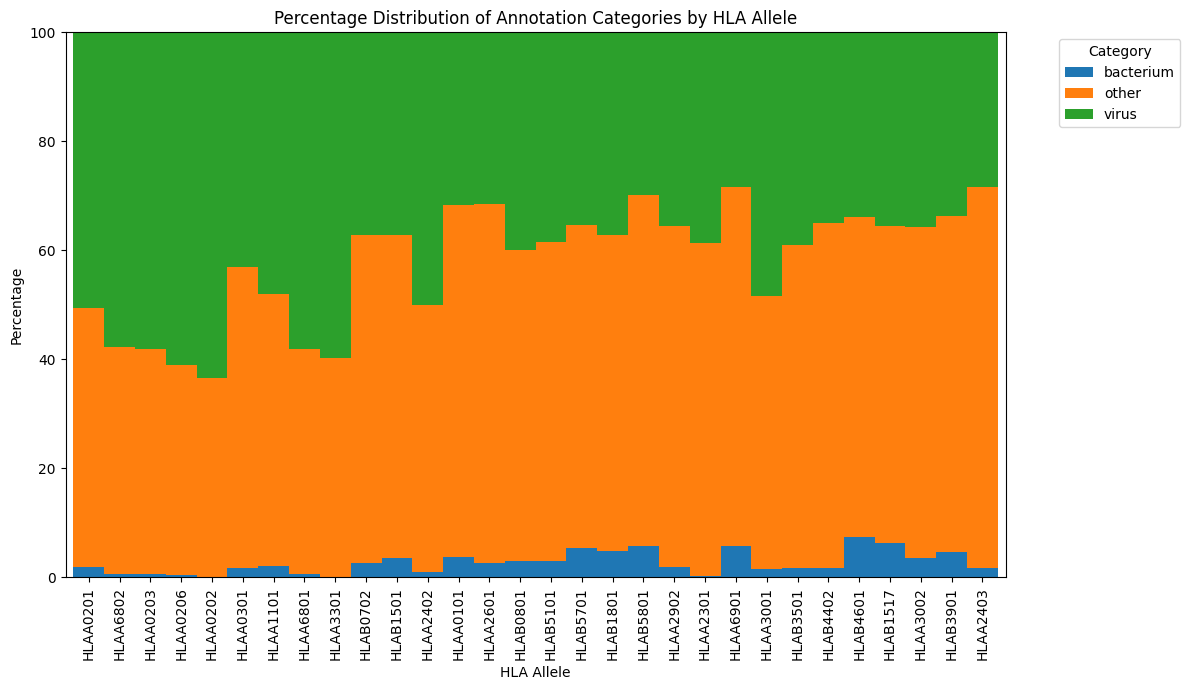

In [ ]:
import matplotlib.pyplot as plt

# Remove columns where the sum of counts (across all categories) is zero
aggregated_table_subset_filtered = aggregated_table_subset.loc[:, aggregated_table_subset.sum(axis=0) != 0]

# Convert counts to percentages per HLA allele (per column)
percent_table = aggregated_table_subset_filtered.div(aggregated_table_subset_filtered.sum(axis=0), axis=1) * 100

# Create the stacked bar graph with width=1 (removes gaps between bars)
fig, ax = plt.subplots(figsize=(12, 7))
percent_table.T.plot(kind='bar', stacked=True, ax=ax, width=1)

# Remove borders between bar segments
for patch in ax.patches:
    patch.set_linewidth(0)
    patch.set_edgecolor('none')

# Set axis labels and title
ax.set_xlabel("HLA Allele")
ax.set_ylabel("Percentage")
ax.set_title("Percentage Distribution of Annotation Categories by HLA Allele")
ax.set_ylim(0, 100)
# ax.set_xticklabels([])

# Position the legend outside of the plot area
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
aggregated_table_subset

,HLAA0201,HLAA6802,HLAA0203,HLAA0206,HLAA0202,HLAA0301,HLAA1101,HLAA6801,HLAA3301,HLAB0702,...,HLAA2301,HLAA6901,HLAA3001,HLAB3501,HLAB4402,HLAB4601,HLAB1517,HLAA3002,HLAB3901,HLAA2403
category,,,,,,,,,,,,,,,,,,,,,
bacterium,274,40,33,19,0,113,119,20,0,96,...,6,136,21,29,30,123,88,49,62,22
other,6889,2394,2311,1944,1611,3457,2771,1248,1157,2226,...,1055,1545,681,971,1148,986,819,816,831,851
virus,7325,3312,3251,3066,2782,2693,2660,1760,1721,1376,...,668,665,658,639,634,567,500,482,455,345


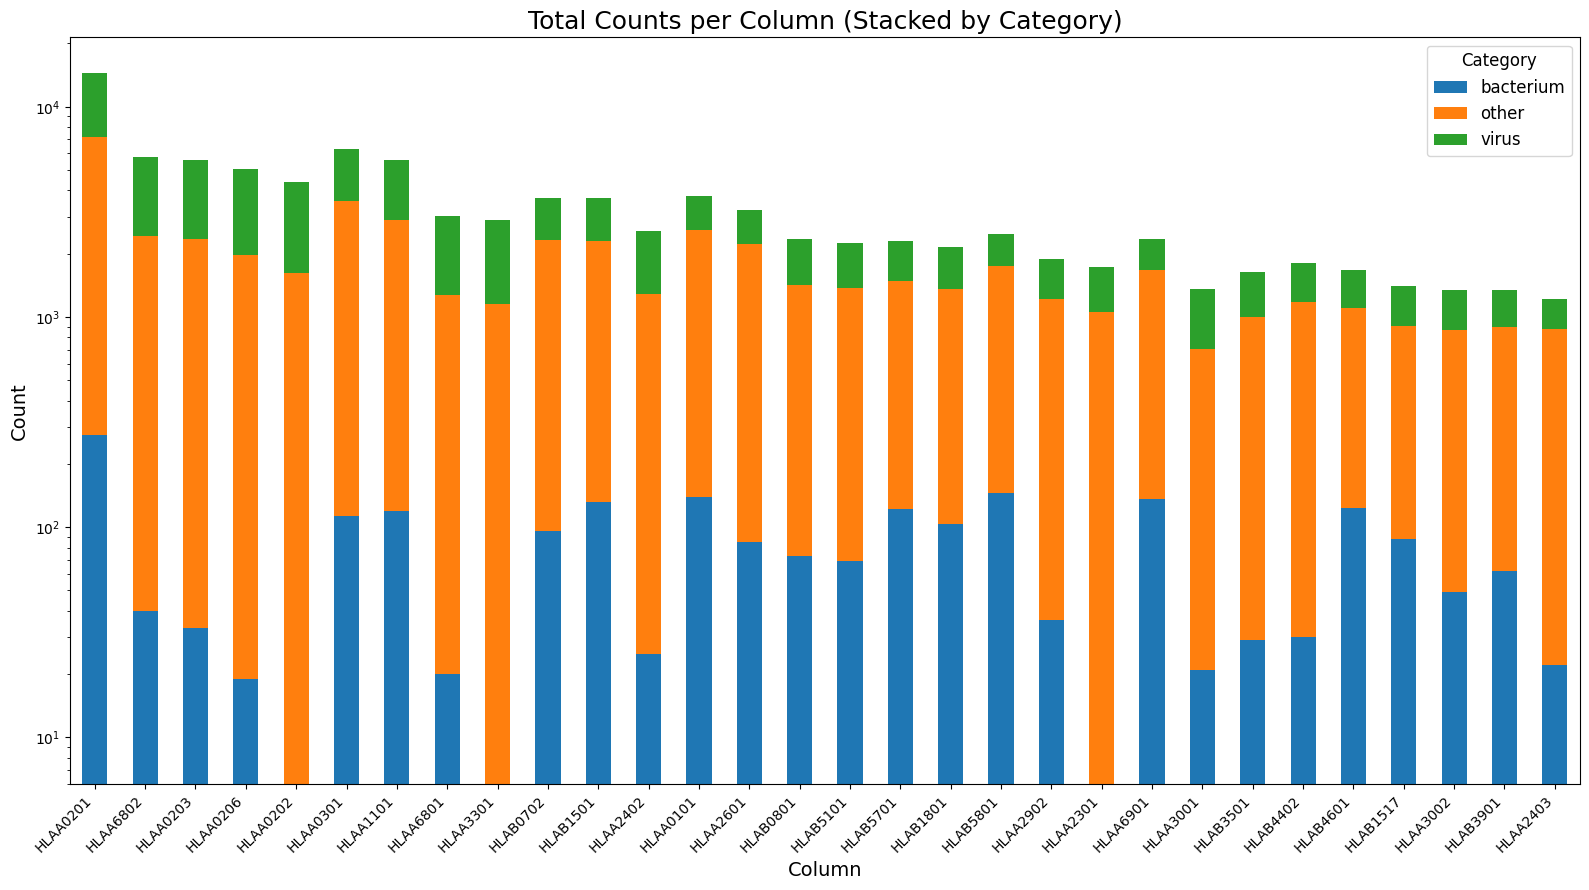

In [ ]:
fig, ax = plt.subplots(figsize=(16, 9))

# Create the stacked bar plot.
aggregated_table_subset.T.plot(kind='bar', stacked=True, ax=ax)

# Set the title and axis labels.
ax.set_title("Total Counts per Column (Stacked by Category)", fontsize=18)
ax.set_xlabel("Column", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
ax.legend(title="Category", fontsize=12, title_fontsize=12)


plt.yscale('log')
# Rotate the x-tick labels for readability.
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [ ]:
all_hlas[9] = all_hlas[9].astype('str')
all_hlas[9] = all_hlas[9].replace(r'\N', 0)
all_hlas[9] = all_hlas[9].astype('float')

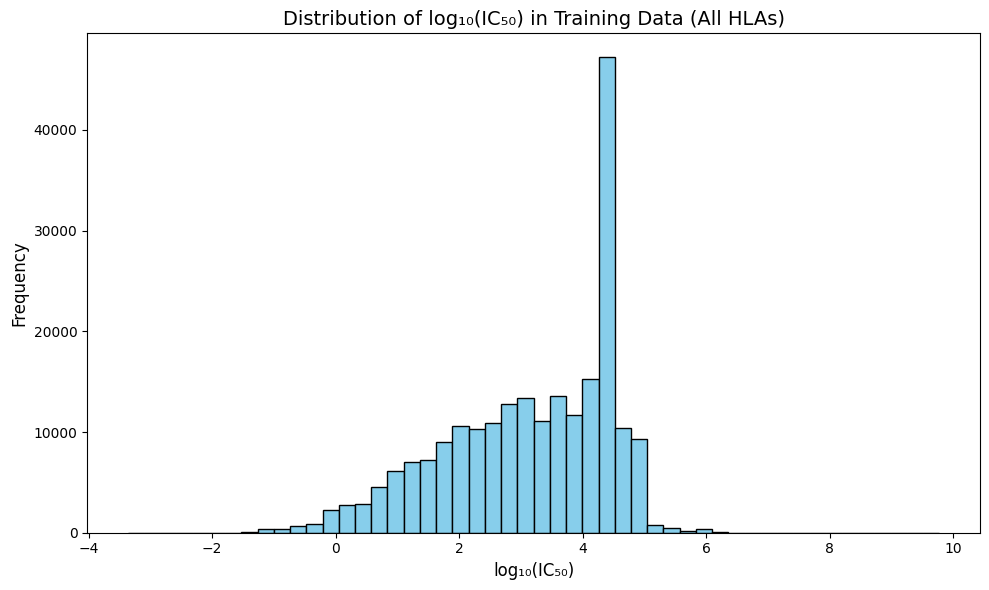

/tmp/ipykernel_869434/2395572855.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=9, y='log_IC50', data=all_hlas_violin, inner='quartile', palette='pastel')


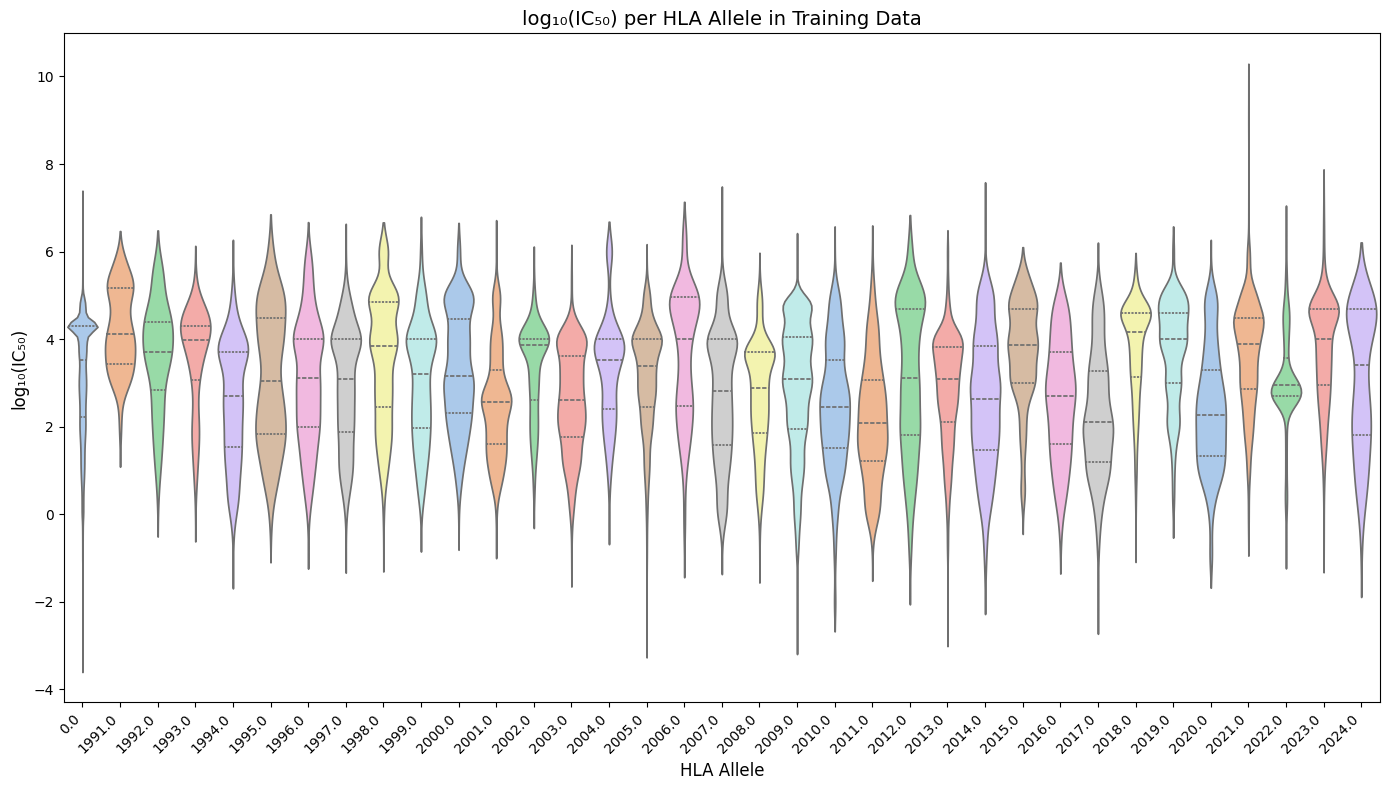

In [ ]:
all_hlas[7] = pd.to_numeric(all_hlas[7], errors='coerce')
all_hlas['log_IC50'] = np.log10(all_hlas[7])

# ------------------------------
# Option 1: Aggregated Histogram
# ------------------------------
plt.figure(figsize=(10, 6))
plt.hist(all_hlas['log_IC50'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel('log₁₀(IC₅₀)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of log₁₀(IC₅₀) in Training Data (All HLAs)', fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------
# Option 2: Violin Plots per HLA Allele
# ------------------------------
# Assume column 9 holds the HLA allele information.
# all_hlas['HLA'] = all_hlas[9]

# Remove rows with missing HLA or log_IC50 values.
all_hlas_violin = all_hlas.dropna(subset=['HLA', 'log_IC50'])

plt.figure(figsize=(14, 8))
sns.violinplot(x=9, y='log_IC50', data=all_hlas_violin, inner='quartile', palette='pastel')
plt.xlabel('HLA Allele', fontsize=12)
plt.ylabel('log₁₀(IC₅₀)', fontsize=12)
plt.title('log₁₀(IC₅₀) per HLA Allele in Training Data', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()